# Choosing Dataset Parameters & `XGBoost` Model Hyperparameters

## Purpose: 

* See the best hyperparameter configurations from each set of sequential, interrelated hyperparameter sweeps. 
* Measure impact of training seed on performance.
* Plot the performance impact from the interplay of multiple inter-related hyperparameters. 
* Retrieve the best model hyperparameter configurations and test performance on outermost fold (holdout).
* Output full data and model hyperparameter configurations for the top models for each cell line and each model type.

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

%load_ext autoreload 
%autoreload 2

import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

import importlib
parameter_analyzer = getattr(
    importlib.import_module("dataset_and_model_parameter_chooser"), 
    "DatasetAndModelParameterAnalyzer"
)


<h1 style="color: teal; font-weight: bold; font-size: 48px;">Load WandB Data & Check Data</h1>

In [2]:
analyzer = parameter_analyzer()

2026-03-07 16:24:54.795 | INFO     | dataset_and_model_parameter_chooser:retrieve_wandb_summary_tables:43 - Retrieving summary tables from WandB
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/jve4pt/.netrc.
2026-03-07 16:24:57.393 | INFO     | dataset_and_model_parameter_chooser:retrieve_wandb_summary_tables:55 - All runs for model sweep are already cached, skipping retrieval from WandB
2026-03-07 16:24:57.919 | INFO     | dataset_and_model_parameter_chooser:retrieve_wandb_summary_tables:55 - All runs for linear sweep are already cached, skipping retrieval from WandB
2026-03-07 16:24:57.920 | WARNING  | dataset_and_model_parameter_chooser:retrieve_wandb_summary_tables:111 - REMINDER: removing early_stopping_rounds outside of 100
2026-03-07 16:24:57.922 | INFO     | dataset_and_model_parameter_chooser:retri

In [3]:
analyzer.run_summary_table_assertions()

2026-03-07 16:24:58.297 | INFO     | dataset_and_model_parameter_chooser:run_summary_table_assertions:129 - Running assertions on summary tables
2026-03-07 16:24:58.298 | INFO     | dataset_and_model_parameter_chooser:run_summary_table_assertions:132 - Running assertions for model summary table
2026-03-07 16:24:58.361 | INFO     | dataset_and_model_parameter_chooser:run_summary_table_assertions:132 - Running assertions for linear summary table
2026-03-07 16:24:58.388 | SUCCESS  | dataset_and_model_parameter_chooser:run_summary_table_assertions:162 - All assertions passed


In [4]:
for type in analyzer.sweep_results:
    type
    analyzer.sweep_results[type].head()

'model'

,run_id,run_name,state,sweep_name,sweep_id,model.name,model.gamma,dataset.name,model.n_jobs,training.seed,model.max_depth,model.objective,model.reg_alpha,model.subsample,model.reg_lambda,training.loss_fn,model.eval_metric,platiglib_project,model.n_estimators,model.learning_rate,training.batch_size,training.pin_memory,training.num_workers,training.wandb.track,dataset.target_fields,training.wandb.entity,model.colsample_bytree,model.min_child_weight,training.profile.plots,training.wandb.project,dataset.fold_filter.seed,dataset.fold_filter.side,training.profile.metrics,training.wandb.save_code,training.wandb.save_model,training.wandb.save_plots,training.data_split.method,model.early_stopping_rounds,training.persistent_workers,dataset.fold_filter.num_folds,training.data_split.num_folds,training.wandb.save_artifacts,dataset.fold_filter.fold_index,training.profile.final_metrics,training.wandb.log_fold_metrics,training.wandb.save_predictions,dataset.fold_filter.group_column,training.data_split.group_column,training.wandb.log_training_plots,training.wandb.log_baseline_metrics,training.wandb.log_training_metrics,training.data_split.validate_frac_of_train,dataset.features.binding_matrix.in_silico_kd,dataset.features.binding_matrix.binding_format,dataset.data_source.EncodeRBPBindingDataSource.window,dataset.data_source.EncodeRBPBindingDataSource.cell_line,dataset.data_source.EncodeRBPBindingDataSource.min_read_count,dataset.data_source.EncodeRBPBindingDataSource.three_exon_combos,cv_loss,cv_mean_absolute_error,cv_mean_absolute_error_std,cv_r2_score,cv_r2_score_std,cv_rmse,cv_rmse_std,holdout_loss,holdout_mean_absolute_error,holdout_r2_score,holdout_rmse,outer_loop_holdout_loss,outer_loop_holdout_mean_absolute_error,outer_loop_holdout_r2_score,outer_loop_holdout_rmse
0,009kebvw,fiery-sweep-279,finished,1:early_stopping_rounds-learning_rate-max_depth,jd8kv80y,XGBRegressor,0.0,RBPSEDataset,-1,600,11,reg:logistic,0.0,1.0,1.0,mean_squared_error,"['rmse', 'logloss']",rbpse,100000,0.10,1024,True,4,True,['target_psi'],platiglab,1.0,1,"['fancy_scatter', 'cumul_resid_dist', ['wandb_faux_pr_curve', {'thresh': 0.5}], ['wandb_faux_roc_curve', {'thresh': 0.5}]]",yogi-rbp-ml-gencode-v24-v29-matching-exons,17,train,"['r2_score', 'mean_absolute_error', 'rmse']",False,False,False,cross_validation,100,True,5,5,False,1,[],False,False,ensembl_gene_id,ensembl_gene_id,False,False,True,0.1,True,binary,100,K562,40,all,0.07905,0.1790,0.001384,0.2706,0.011390,0.2812,0.001776,0.07905,0.1791,0.2711,0.2812,NaN,NaN,NaN,NaN
1,00hq0eth,lilac-sweep-227,finished,1:early_stopping_rounds-learning_rate-max_depth,jd8kv80y,XGBRegressor,0.0,RBPSEDataset,-1,300,7,reg:logistic,0.0,1.0,1.0,mean_squared_error,"['rmse', 'logloss']",rbpse,100000,0.05,1024,True,4,True,['target_psi'],platiglab,1.0,1,"['fancy_scatter', 'cumul_resid_dist', ['wandb_faux_pr_curve', {'thresh': 0.5}], ['wandb_faux_roc_curve', {'thresh': 0.5}]]",yogi-rbp-ml-gencode-v24-v29-matching-exons,17,train,"['r2_score', 'mean_absolute_error', 'rmse']",False,False,False,cross_validation,100,True,5,5,False,1,[],False,False,ensembl_gene_id,ensembl_gene_id,False,False,True,0.1,True,binary,100,K562,40,all,0.07888,0.1803,0.003421,0.2726,0.009745,0.2808,0.004178,0.07888,0.1803,0.2727,0.2809,NaN,NaN,NaN,NaN
2,0149fzlw,toasty-sweep-245,finished,1:early_stopping_rounds-learning_rate-max_depth,jd8kv80y,XGBRegressor,0.0,RBPSEDataset,-1,700,11,reg:logistic,0.0,1.0,1.0,mean_squared_error,"['rmse', 'logloss']",rbpse,100000,0.05,1024,True,4,True,['target_psi'],platiglab,1.0,1,"['fancy_scatter', 'cumul_resid_dist', ['wandb_faux_pr_curve', {'thresh': 0.5}], ['wandb_faux_roc_curve', {'thresh': 0.5}]]",yogi-rbp-ml-gencode-v24-v29-matching-exons,17,train,"['r2_score', 'mean_absolute_error', 'rmse']",False,False,False,cross_validation,100,True,5,5,False,1,[],False,False,ensembl_gene_id,ensembl_gene_id,False,False,True,0.1,True,binary,100,K562,40,all,0.07867,0.1792,0.004046,0.2743,0.007799,0.2804,0.006459,0.07867,0.1791,0.2746,0.2805,NaN,NaN,

'linear'

,run_id,run_name,state,sweep_name,sweep_id,model.name,model.alpha,dataset.name,training.seed,model.l1_ratio,training.loss_fn,platiglib_project,training.batch_size,training.pin_memory,training.num_workers,training.wandb.track,dataset.target_fields,training.wandb.entity,training.profile.plots,training.wandb.project,dataset.fold_filter.seed,dataset.fold_filter.side,training.profile.metrics,training.wandb.save_code,training.wandb.save_model,training.wandb.save_plots,training.data_split.method,training.persistent_workers,dataset.fold_filter.num_folds,training.data_split.num_folds,training.wandb.save_artifacts,dataset.fold_filter.fold_index,training.profile.final_metrics,training.wandb.log_fold_metrics,training.wandb.save_predictions,dataset.fold_filter.group_column,training.data_split.group_column,training.wandb.log_training_plots,training.wandb.log_baseline_metrics,training.wandb.log_training_metrics,dataset.features.binding_matrix.in_silico_kd,dataset.features.binding_matrix.binding_format,dataset.data_source.EncodeRBPBindingDataSource.window,dataset.data_source.EncodeRBPBindingDataSource.cell_line,dataset.data_source.EncodeRBPBindingDataSource.min_read_count,dataset.data_source.EncodeRBPBindingDataSource.three_exon_combos,cv_loss,cv_r2_score,cv_r2_score_std,cv_rmse,cv_rmse_std,cv_sigmoid_r2,cv_sigmoid_r2_std,holdout_loss,holdout_r2_score,holdout_rmse,holdout_sigmoid_r2,outer_loop_holdout_loss,outer_loop_holdout_r2_score,outer_loop_holdout_rmse,outer_loop_holdout_sigmoid_r2
0,00v9xcf4,glowing-sweep-921,finished,ElasticNet,k2unw4uu,ElasticNet,1.0000,RBPSEDataset,400,1.0,mean_squared_error,rbpse,1024,True,4,True,['target_psi'],platiglab,"['fancy_scatter', 'cumul_resid_dist', ['wandb_faux_pr_curve', {'thresh': 0.5}], ['wandb_faux_roc_curve', {'thresh': 0.5}]]",yogi-linear-models-gencode-v24-v29-matching-exons,17,train,"['r2_score', 'rmse', 'sigmoid_r2']",False,False,False,cross_validation,True,5,5,False,1,[],False,False,ensembl_gene_id,ensembl_gene_id,False,False,True,True,binary,100,HepG2,40,all,0.11500,-0.000120,0.000144,0.3391,0.003910,-0.14600,0.01012,0.11500,-0.000043,0.3391,-0.14580,NaN,NaN,NaN,NaN
1,020zwnfo,wobbly-sweep-351,finished,ElasticNet,k2unw4uu,ElasticNet,1.0000,RBPSEDataset,100,0.5,mean_squared_error,rbpse,1024,True,4,True,['target_psi'],platiglab,"['fancy_scatter', 'cumul_resid_dist', ['wandb_faux_pr_curve', {'thresh': 0.5}], ['wandb_faux_roc_curve', {'thresh': 0.5}]]",yogi-linear-models-gencode-v24-v29-matching-exons,17,train,"['r2_score', 'rmse', 'sigmoid_r2']",False,False,False,cross_validation,True,5,5,False,1,[],False,False,ensembl_gene_id,ensembl_gene_id,False,False,True,True,binary,100,K562,40,all,0.10850,-0.000764,0.000728,0.3293,0.006451,-0.17700,0.02548,0.10850,-0.000283,0.3294,-0.17530,NaN,NaN,NaN,NaN
2,025bzauf,driven-sweep-704,finished,ElasticNet,k2unw4uu,ElasticNet,0.0050,RBPSEDataset,400,0.9,mean_squared_error,rbpse,1024,True,4,True,['target_psi'],platiglab,"['fancy_scatter', 'cumul_resid_dist', ['wandb_faux_pr_curve', {'thresh': 0.5}], ['wandb_faux_roc_curve', {'thresh': 0.5}]]",yogi-linear-models-gencode-v24-v29-matching-exons,17,train,"['r2_score', 'rmse', 'sigmoid_r2']",False,False,False,cross_validation,True,5,5,False,1,[],False,False,ensembl_gene_id,ensembl_gene_id,False,False,True,True,binary,100,HepG2,40,all,0.10340,0.101100,0.005984,0.3215,0.003726,-0.11640,0.01149,0.10330,0.101300,0.3214,-0.11610,NaN,NaN,NaN,NaN
3,0267xvmy,azure-sweep-565,finished,ElasticNet,k2unw4uu,ElasticNet,0.0001,RBPSEDataset,500,0.5,mean_squared_error,rbpse,1024,True,4,True,['target_psi'],platiglab,"['fancy_scatter', 'cumul_resid_dist', ['wandb_faux_pr_curve', {'thresh': 0.5}], ['wandb_faux_roc_curve', {'thresh': 0.5}]]",yogi-linear-models-gencode-v24-v29-matching-exons,17,train,"['r2_score', 'rmse', 'sigmoid_r2']",False,False,False,cross_validation,True,5,5,False,1,[],False,False,ensembl_gene_id,ensembl_gene_id,False,False,True,True,binary,100,HepG2,40,all,0.09380,0.183900,0.007917,0.3062,0.003642,-0.07398,0.01287,0.

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Rank Hyperparameter Choices While Running Sequential Sweeps</h1>

In [5]:
dfs = analyzer.show_top_model_configs_after_averaging_by_seed(all_configs=False, linear=False)

for key in dfs: 
    key
    dfs[key]

'1:early_stopping_rounds-learning_rate-max_depth'

,model.early_stopping_rounds,model.learning_rate,model.max_depth,dataset.data_source.EncodeRBPBindingDataSource.cell_line,avg_holdout_r2_score
0,100,0.10,5,HepG2,0.282786
1,100,0.05,5,HepG2,0.282671
2,100,0.01,5,HepG2,0.282629
3,100,0.01,7,HepG2,0.282114
4,100,0.05,7,HepG2,0.282057
5,100,0.10,3,HepG2,0.281743
6,100,0.05,3,HepG2,0.281500
7,100,0.01,9,HepG2,0.281014
8,100,0.10,7,HepG2,0.280914
9,100,0.01,3,HepG2,0.280600


'2:min_child_weight-gamma'

,model.min_child_weight,model.gamma,dataset.data_source.EncodeRBPBindingDataSource.cell_line,avg_holdout_r2_score
0,100,0.5,HepG2,0.284171
1,100,1.0,HepG2,0.284000
2,100,0.0,HepG2,0.283971
3,100,2.0,HepG2,0.283943
4,50,0.5,HepG2,0.283743
5,5,0.0,HepG2,0.283429
6,100,5.0,HepG2,0.283414
7,50,2.0,HepG2,0.283400
8,10,2.0,HepG2,0.283386
9,5,2.0,HepG2,0.283243


'3:subsample-colsample_bytree'

,model.subsample,model.colsample_bytree,dataset.data_source.EncodeRBPBindingDataSource.cell_line,avg_holdout_r2_score
0,0.75,0.75,HepG2,0.284629
1,0.75,0.50,HepG2,0.284571
2,0.50,1.00,HepG2,0.284514
3,1.00,0.50,HepG2,0.284457
4,0.50,0.75,HepG2,0.284443
5,1.00,0.75,HepG2,0.284171
6,1.00,1.00,HepG2,0.284171
7,1.00,0.25,HepG2,0.283957
8,0.50,0.50,HepG2,0.283871
9,0.50,0.25,HepG2,0.283600


'4:reg_alpha-reg_lambda'

,model.reg_alpha,model.reg_lambda,dataset.data_source.EncodeRBPBindingDataSource.cell_line,avg_holdout_r2_score
0,0.0,0.5,HepG2,0.285457
1,0.2,10.0,HepG2,0.285443
2,0.0,10.0,HepG2,0.285057
3,1.0,5.0,HepG2,0.284957
4,0.8,0.5,HepG2,0.284914
5,0.8,5.0,HepG2,0.284786
6,0.0,0.1,HepG2,0.284757
7,0.5,0.1,HepG2,0.284729
8,0.0,5.0,HepG2,0.284657
9,0.2,0.5,HepG2,0.284643


<h1 style="color: teal; font-weight: bold; font-size: 48px;">Overall R2 Distributions for Dataset & Model Hyperparameter Sweeps</h1>

In [ ]:
# analyzer.load_aggreated_data_stats()

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/03_choose_dataset_and_model_parameters/code/dataset_and_model_parameter_chooser.py:380: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x=self.platiglib_cell_line_col, y=y_variable, data=data, palette=['lightblue', 'lightcoral'], linewidth=linewidth, edgecolor='black', size=size)


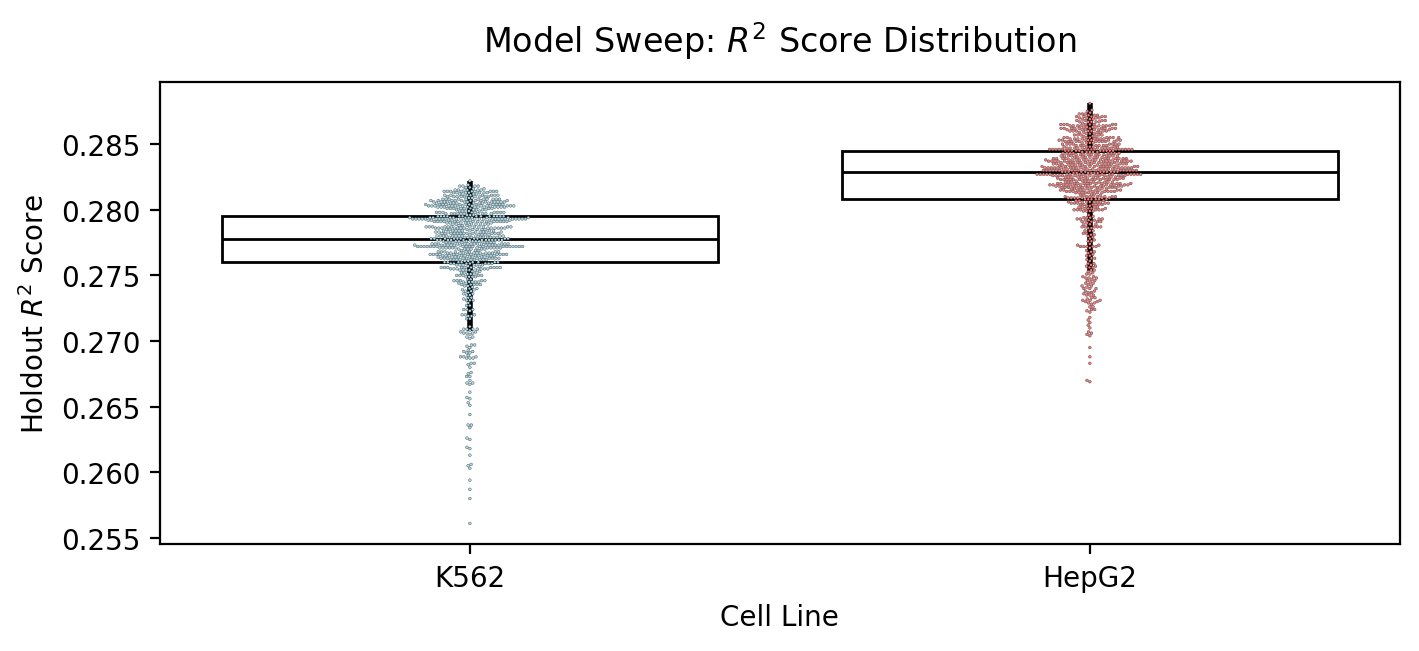

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/03_choose_dataset_and_model_parameters/code/dataset_and_model_parameter_chooser.py:380: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x=self.platiglib_cell_line_col, y=y_variable, data=data, palette=['lightblue', 'lightcoral'], linewidth=linewidth, edgecolor='black', size=size)
/apps/software/standard/core/jupyterlab/4.4.6-py3.12/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/apps/software/standard/core/jupyterlab/4.4.6-py3.12/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 29.3% of the points cannot be placed; you may want to decrease the size of the mark

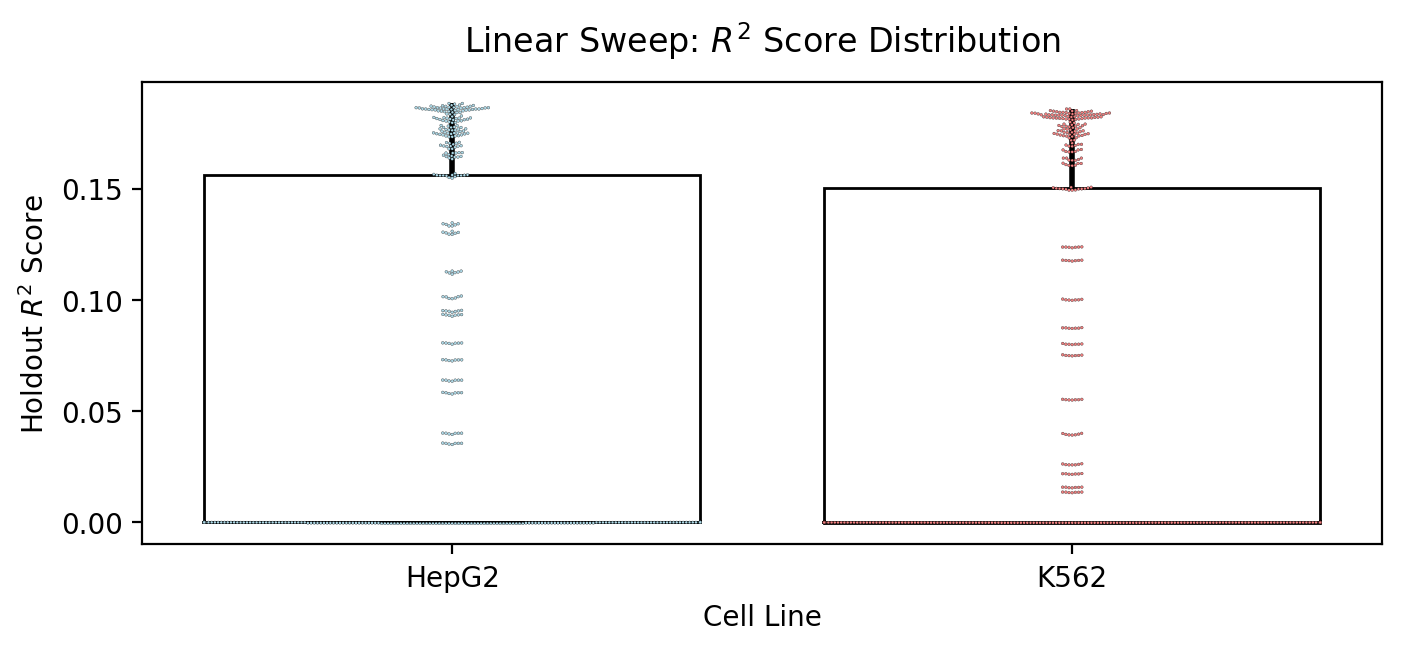

In [6]:
analyzer.plot_r2_distributions()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Dataset Hyperparameter Sweep</h1>

In [ ]:
analyzer.plot_dataset_r2_per_covariate()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Model Hyperparameter Sweeps</h1>

## 1D Range Sweeps

In [ ]:
# analyzer.plot_1D_range_model_hyperparameter_sweeps()

## Inner Fold Splitting Robustness

2026-03-07 16:25:31.206 | WARNING  | dataset_and_model_parameter_chooser:plot_inner_fold_seed_r2_results:499 - REMINDER: Excluding configurations where 'training.seed' is 17


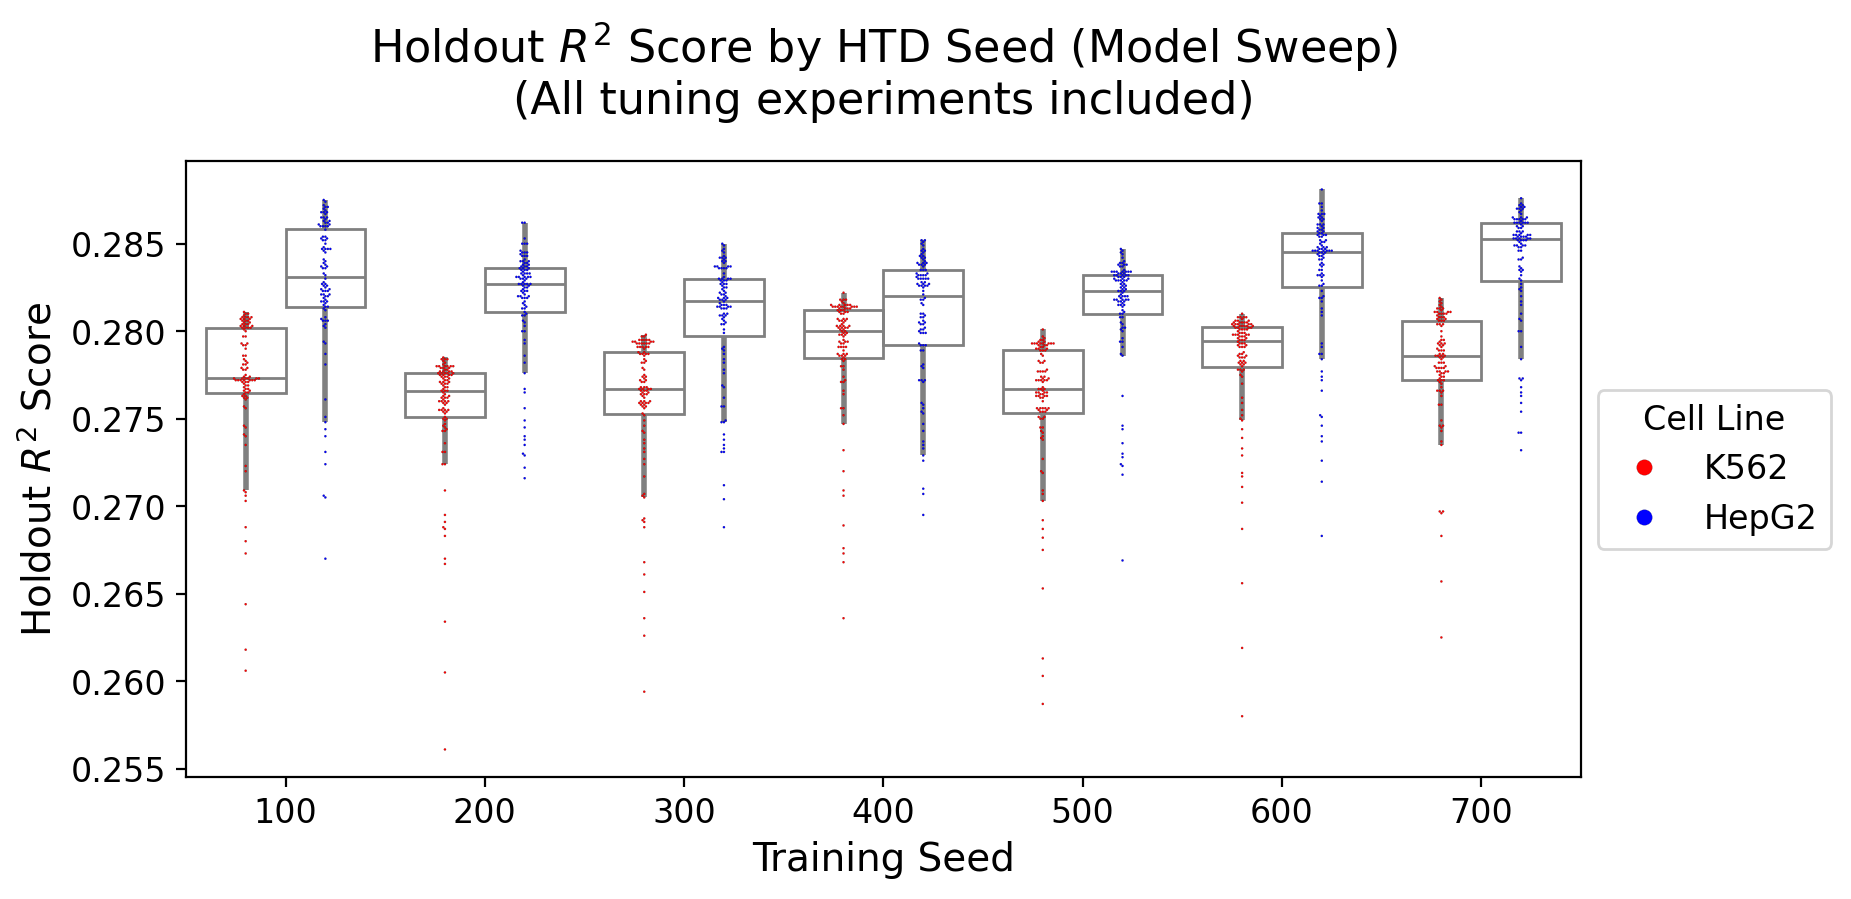

2026-03-07 16:25:33.020 | WARNING  | dataset_and_model_parameter_chooser:plot_inner_fold_seed_r2_results:499 - REMINDER: Excluding configurations where 'training.seed' is 17


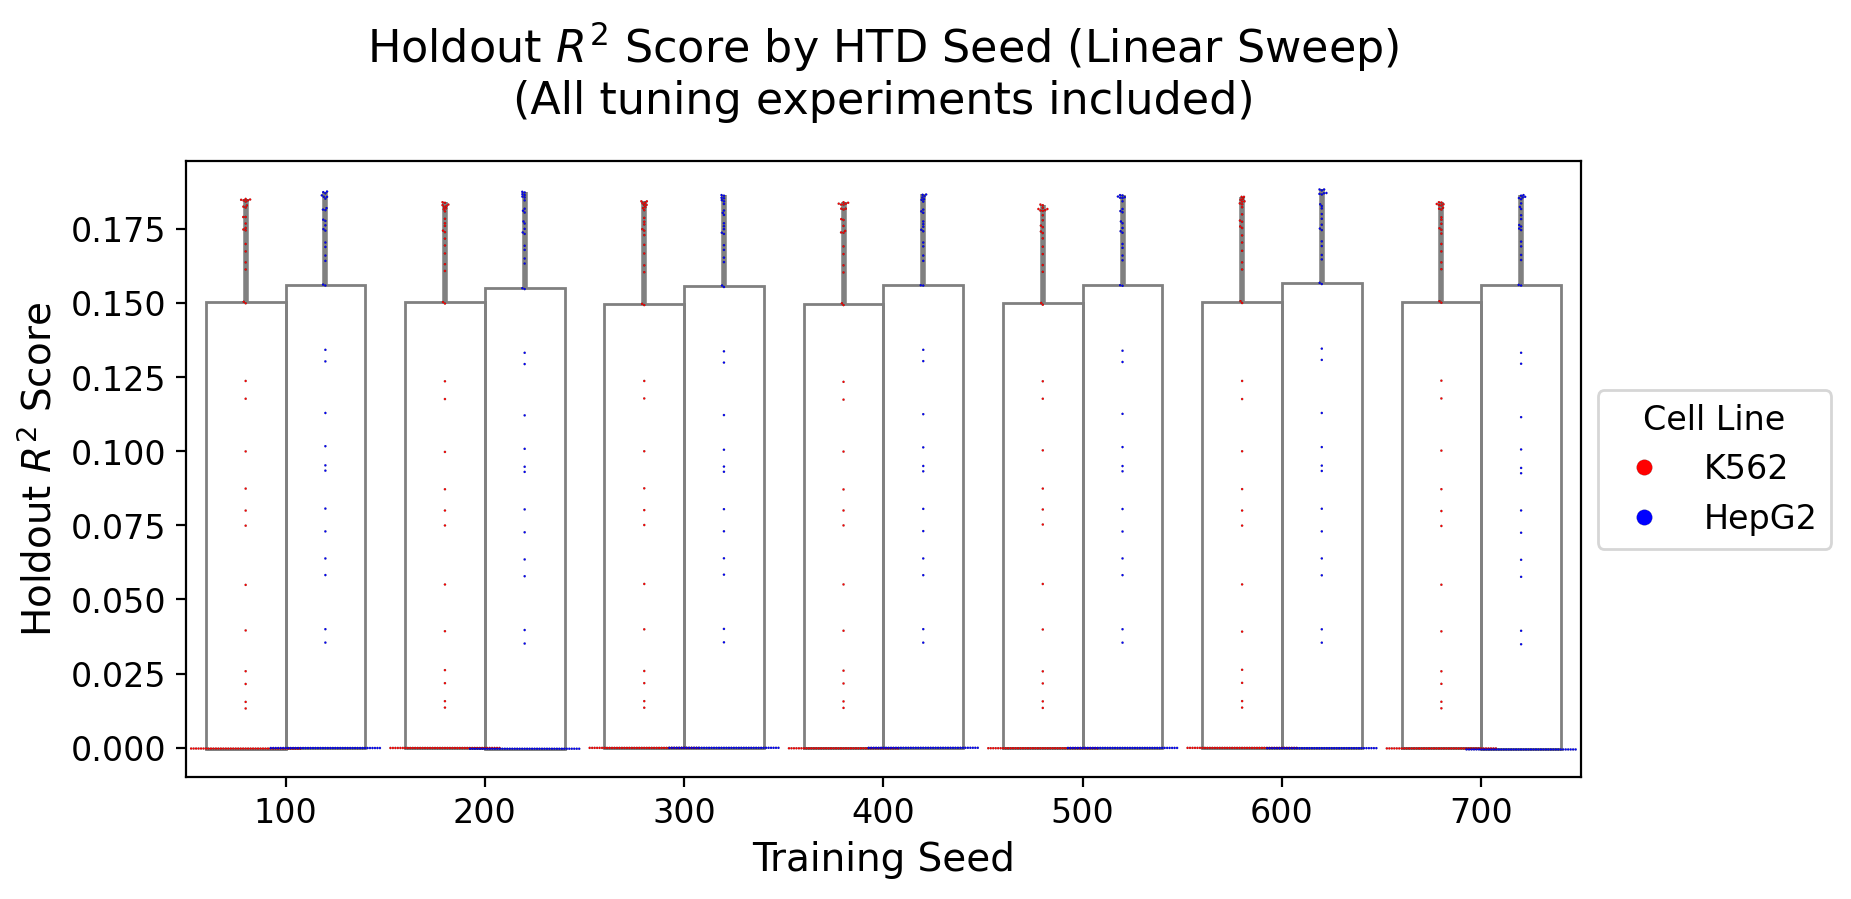

In [7]:
analyzer.plot_inner_fold_seed_r2_results()

## 1D Plotting of Sweep Results

2026-03-07 16:26:10.950 | INFO     | dataset_and_model_parameter_chooser:plot_interrelated_model_hyperparameter_results_in_1D:538 - Plotting for sweep: 1:early_stopping_rounds-learning_rate-max_depth


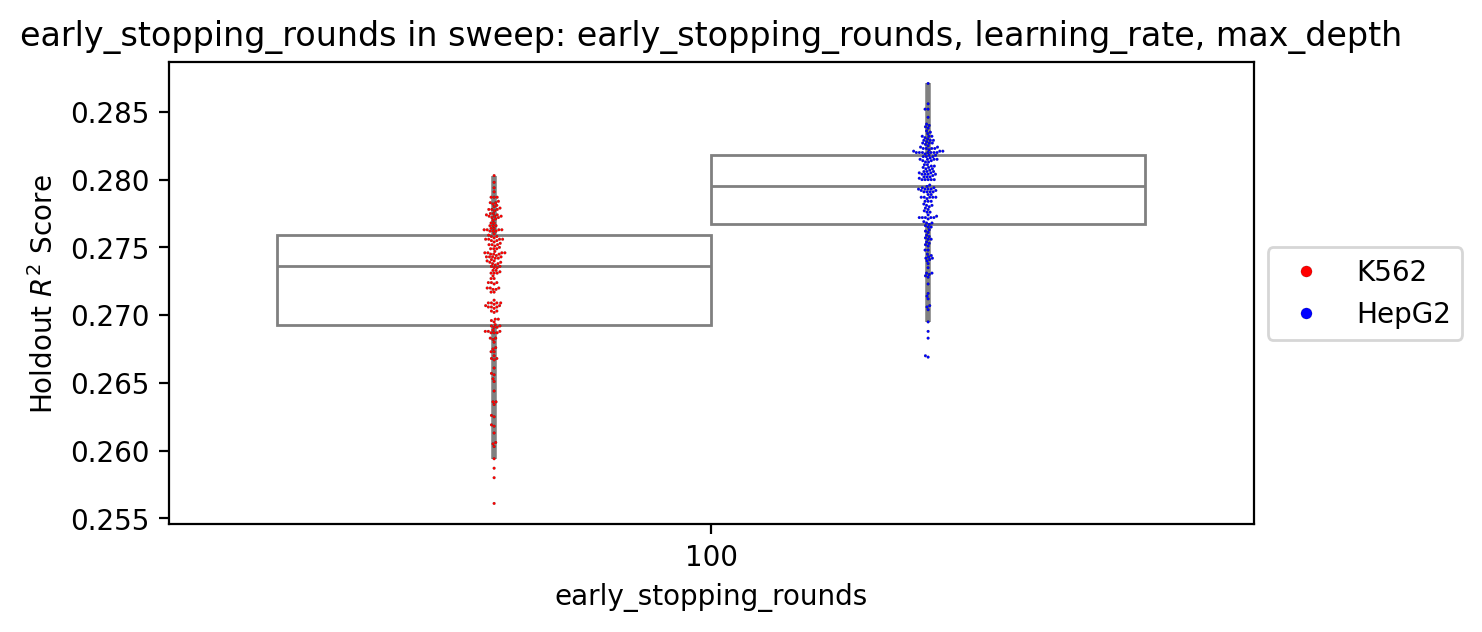

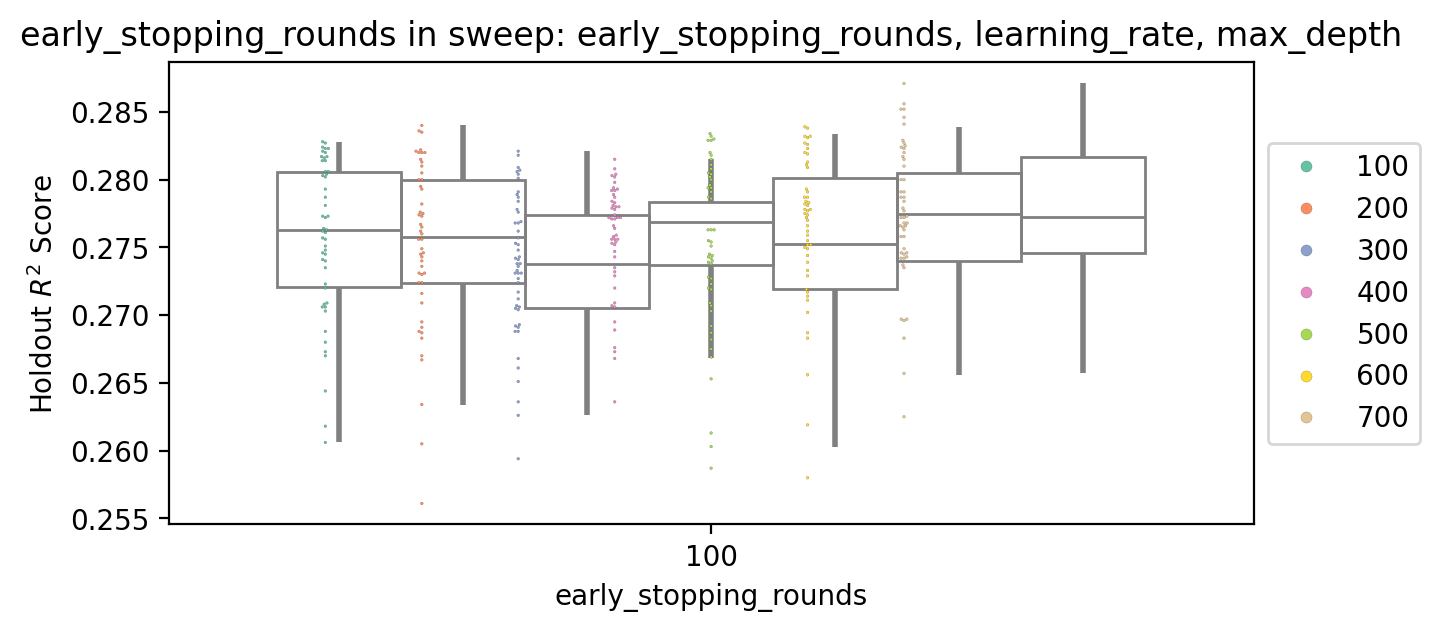

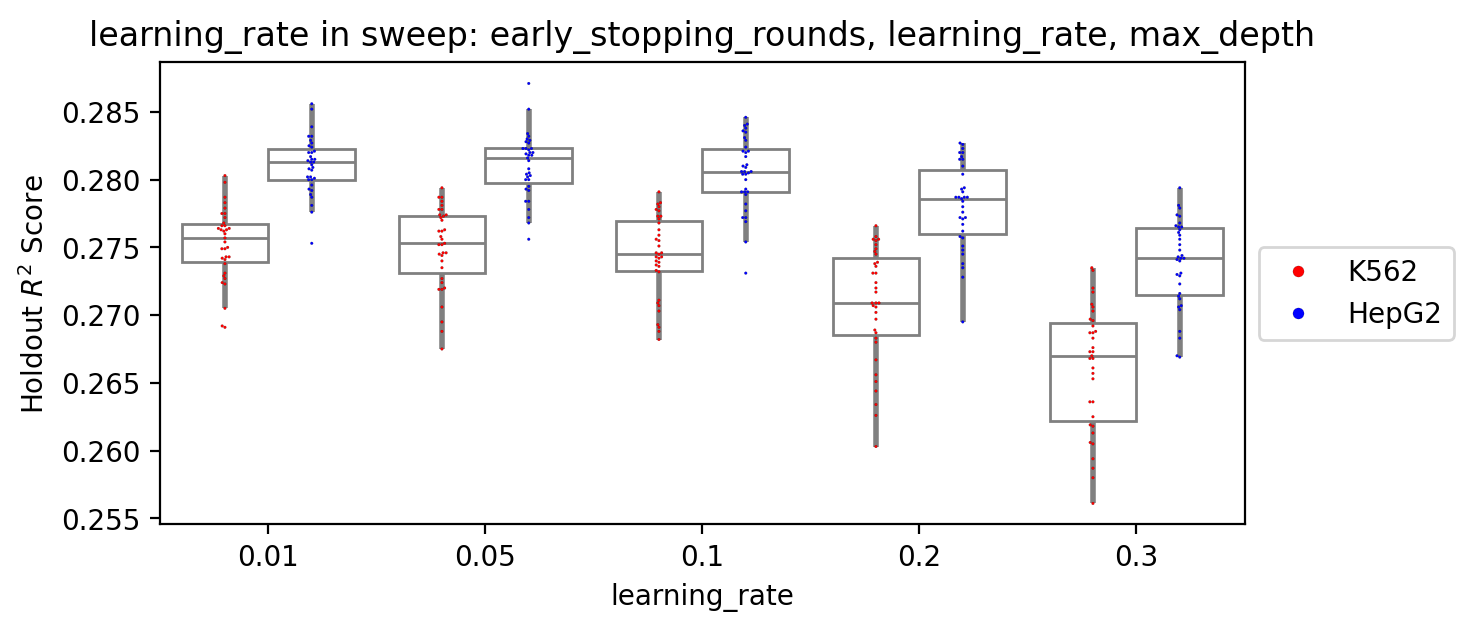

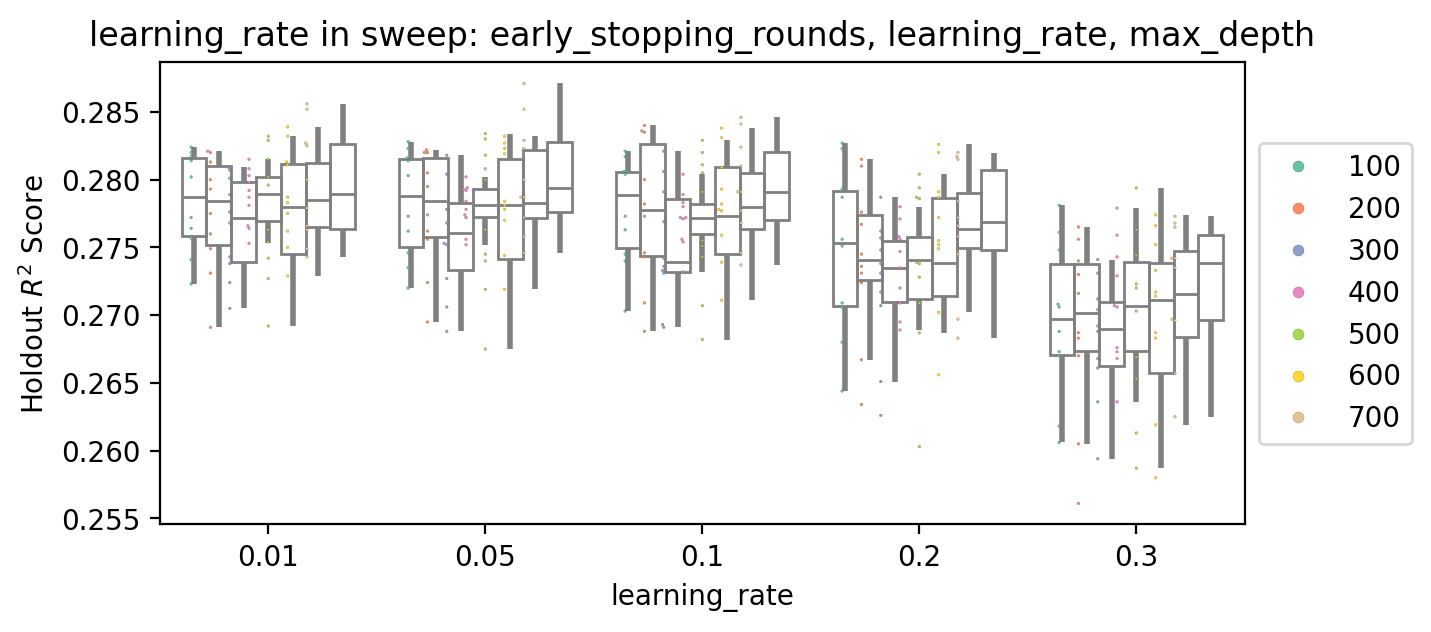

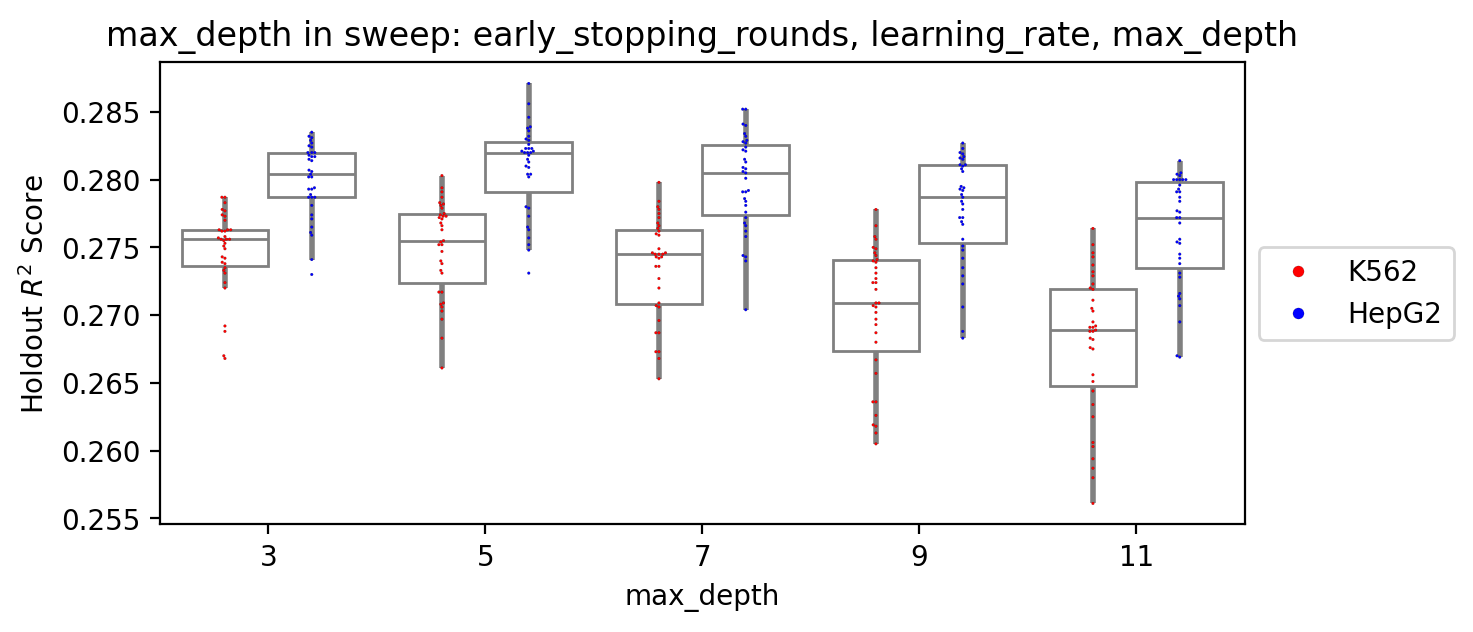

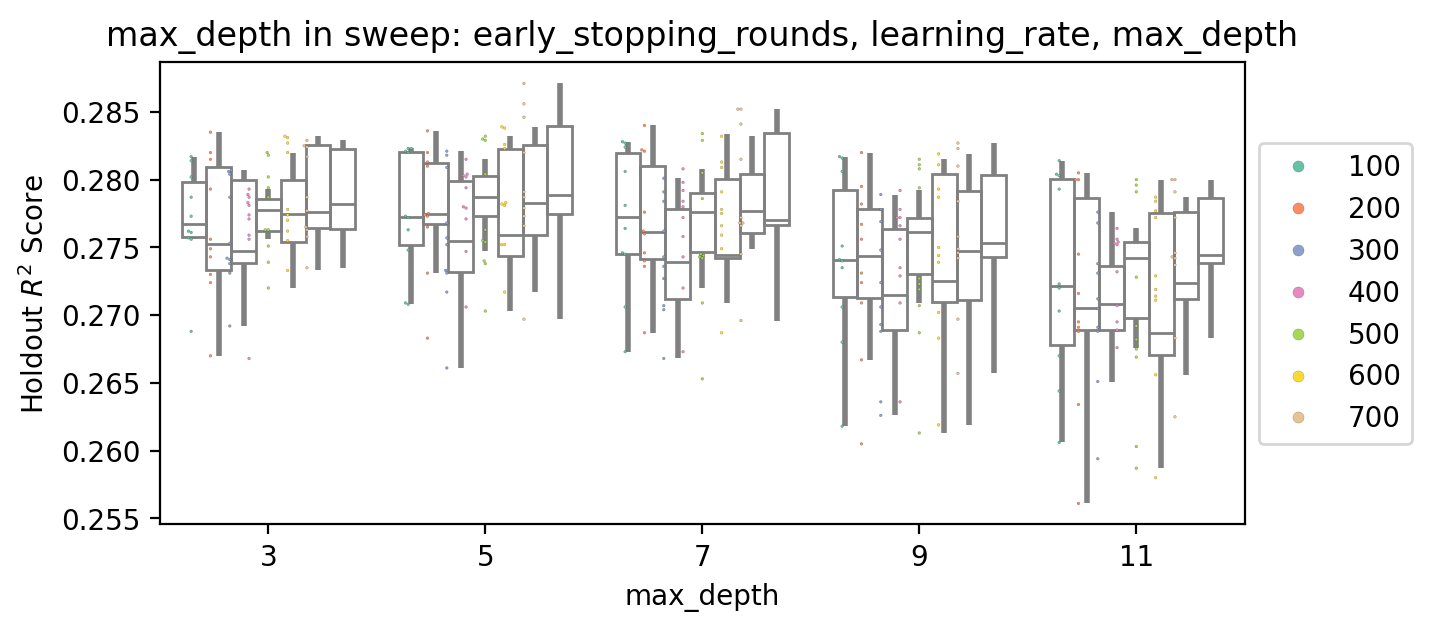

2026-03-07 16:26:14.924 | INFO     | dataset_and_model_parameter_chooser:plot_interrelated_model_hyperparameter_results_in_1D:538 - Plotting for sweep: 2:min_child_weight-gamma


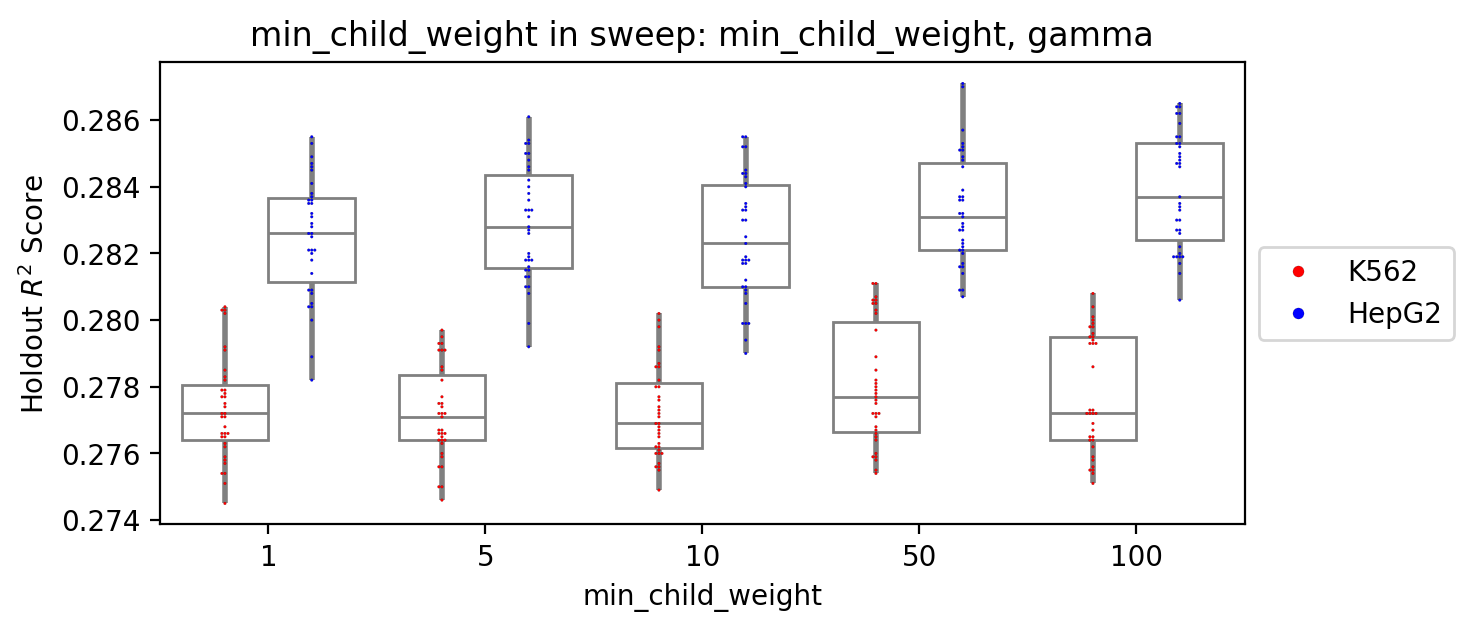

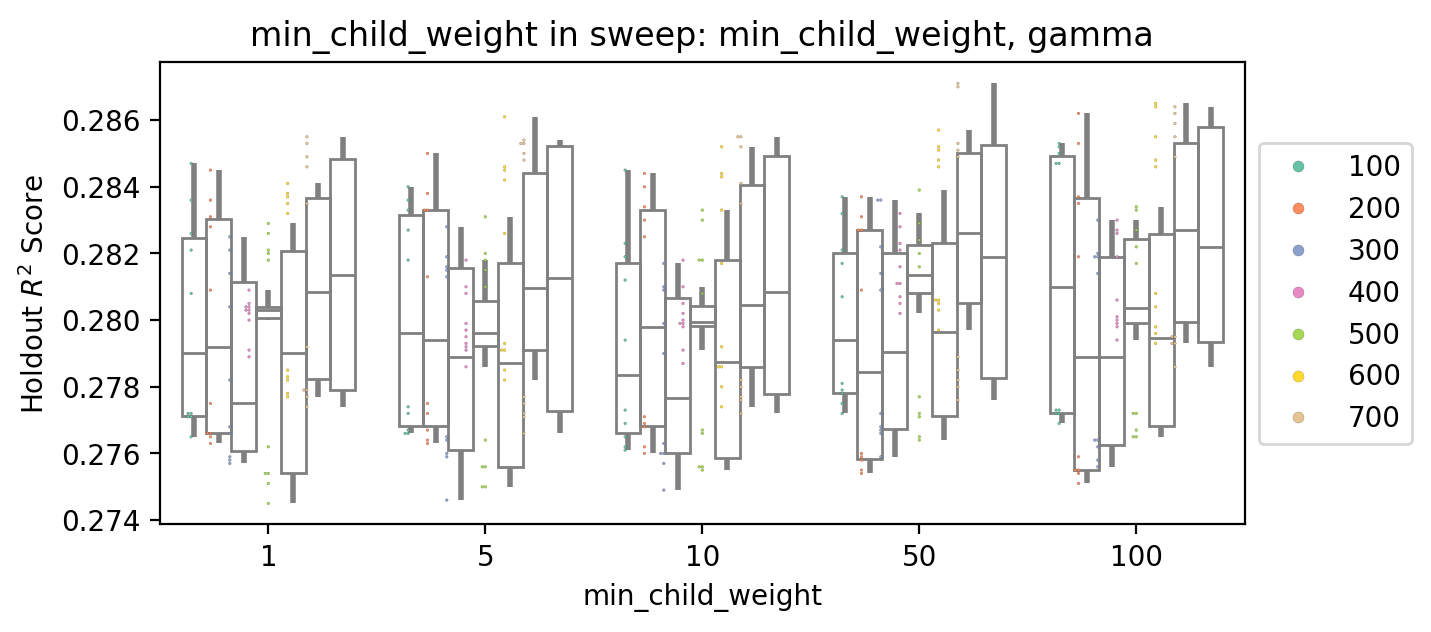

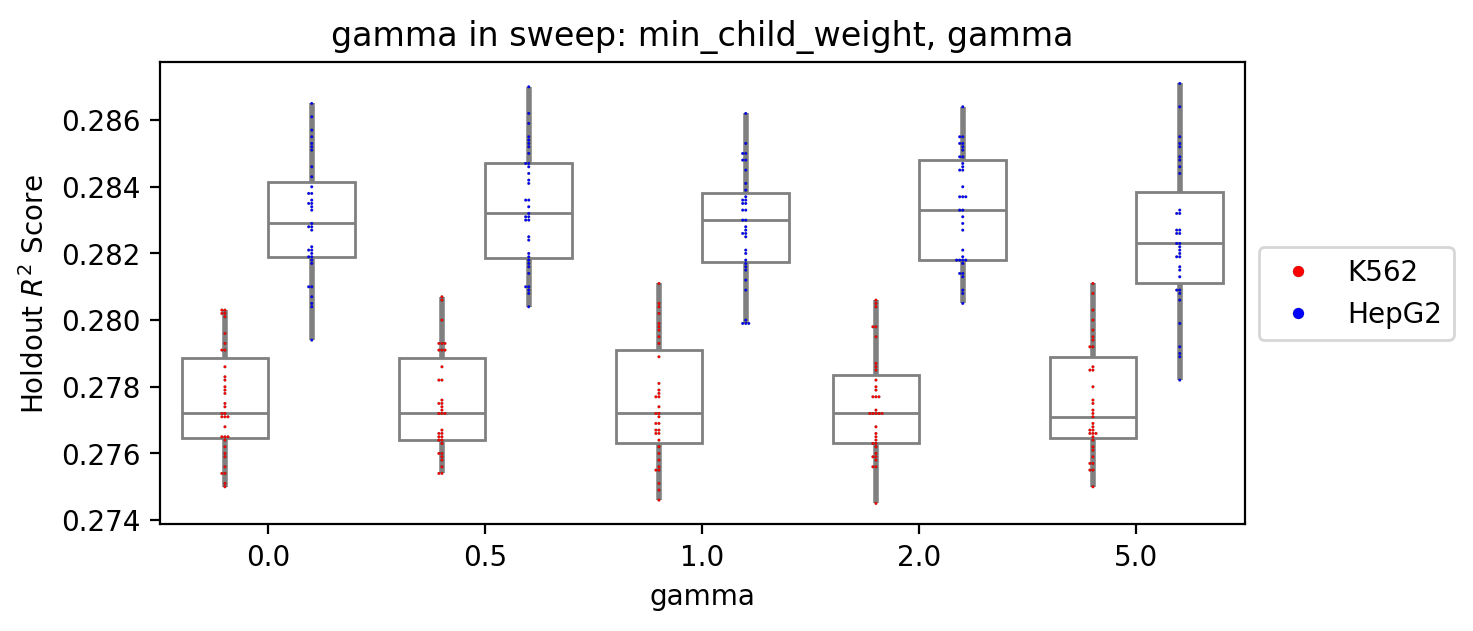

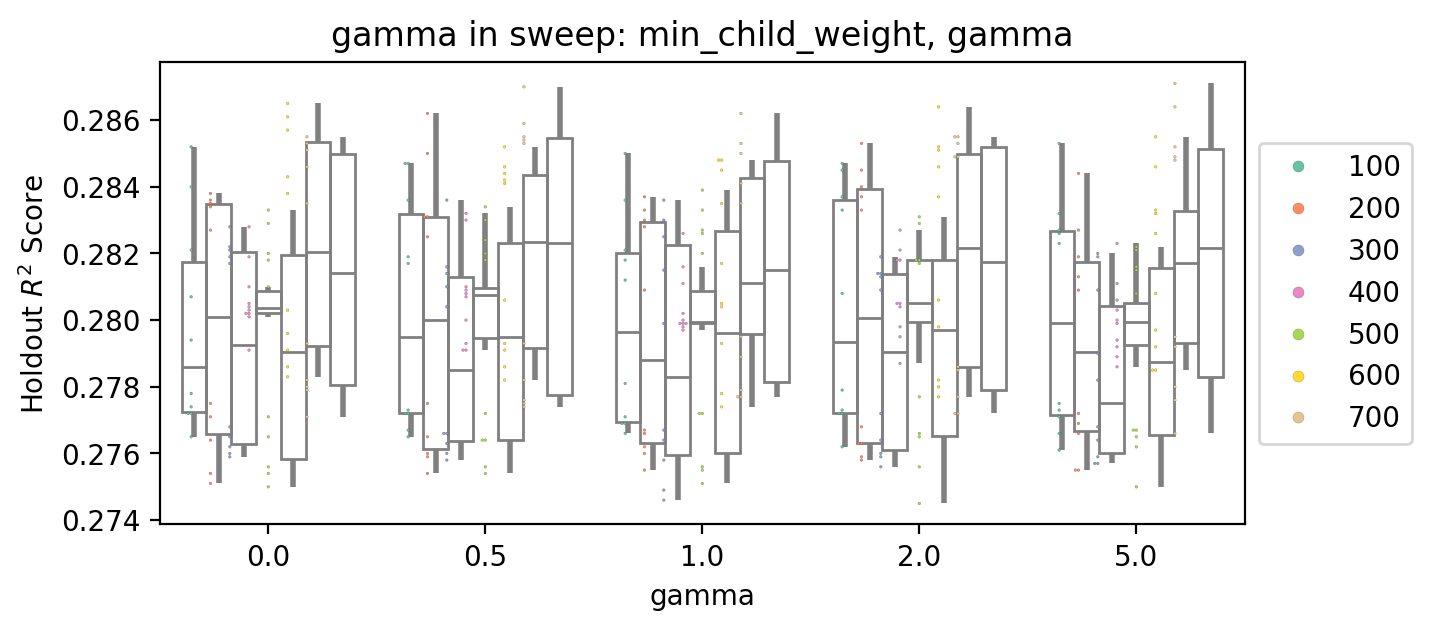

2026-03-07 16:26:17.855 | INFO     | dataset_and_model_parameter_chooser:plot_interrelated_model_hyperparameter_results_in_1D:538 - Plotting for sweep: 3:subsample-colsample_bytree


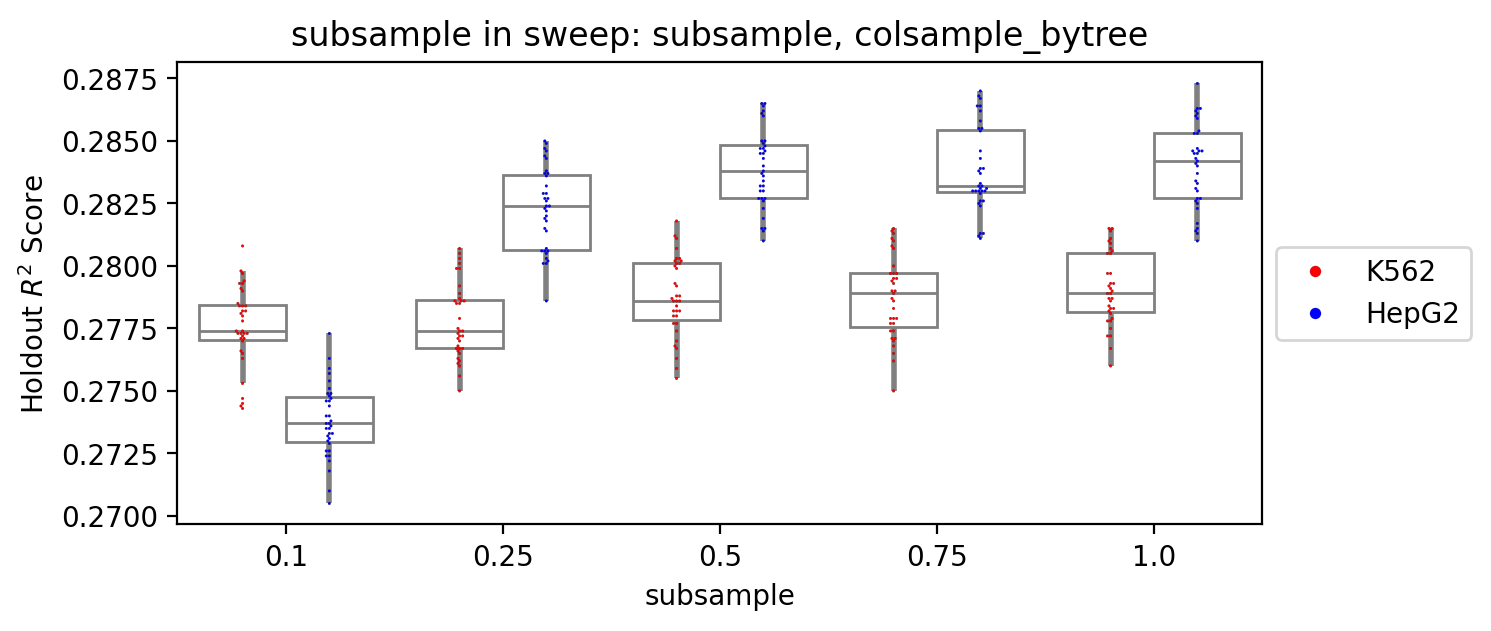

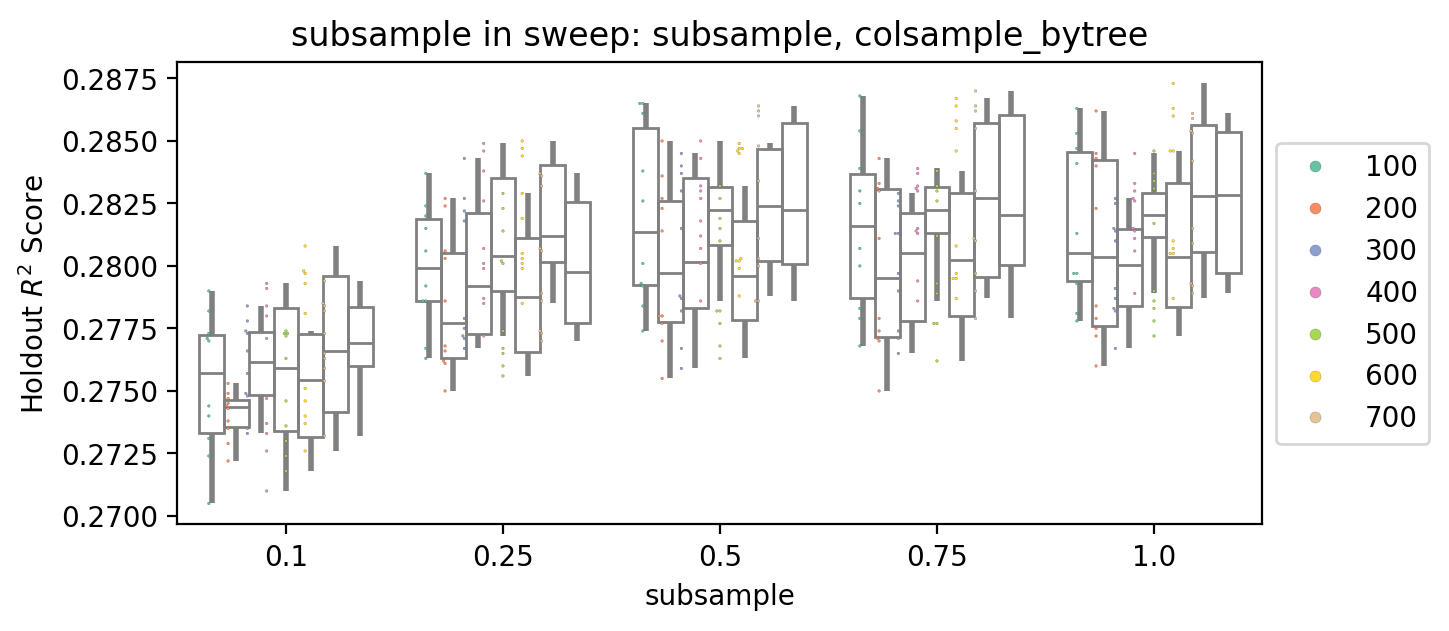

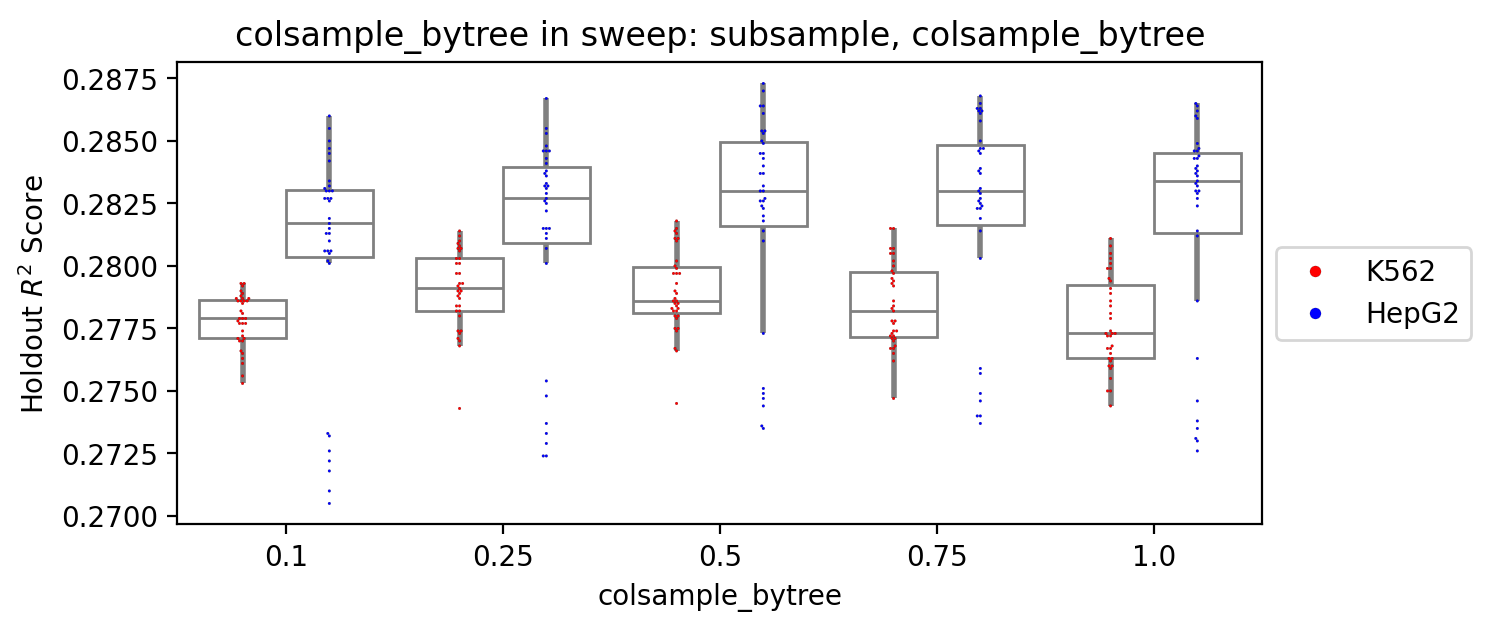

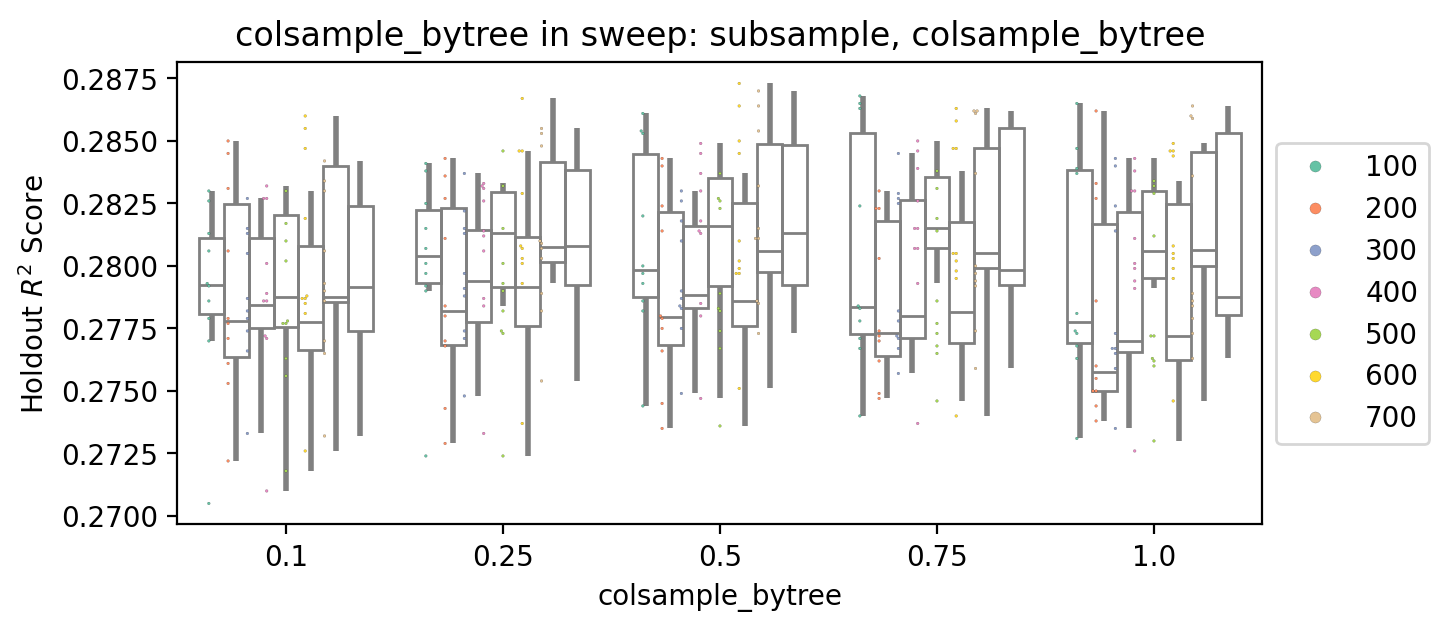

2026-03-07 16:26:20.702 | INFO     | dataset_and_model_parameter_chooser:plot_interrelated_model_hyperparameter_results_in_1D:538 - Plotting for sweep: 4:reg_alpha-reg_lambda


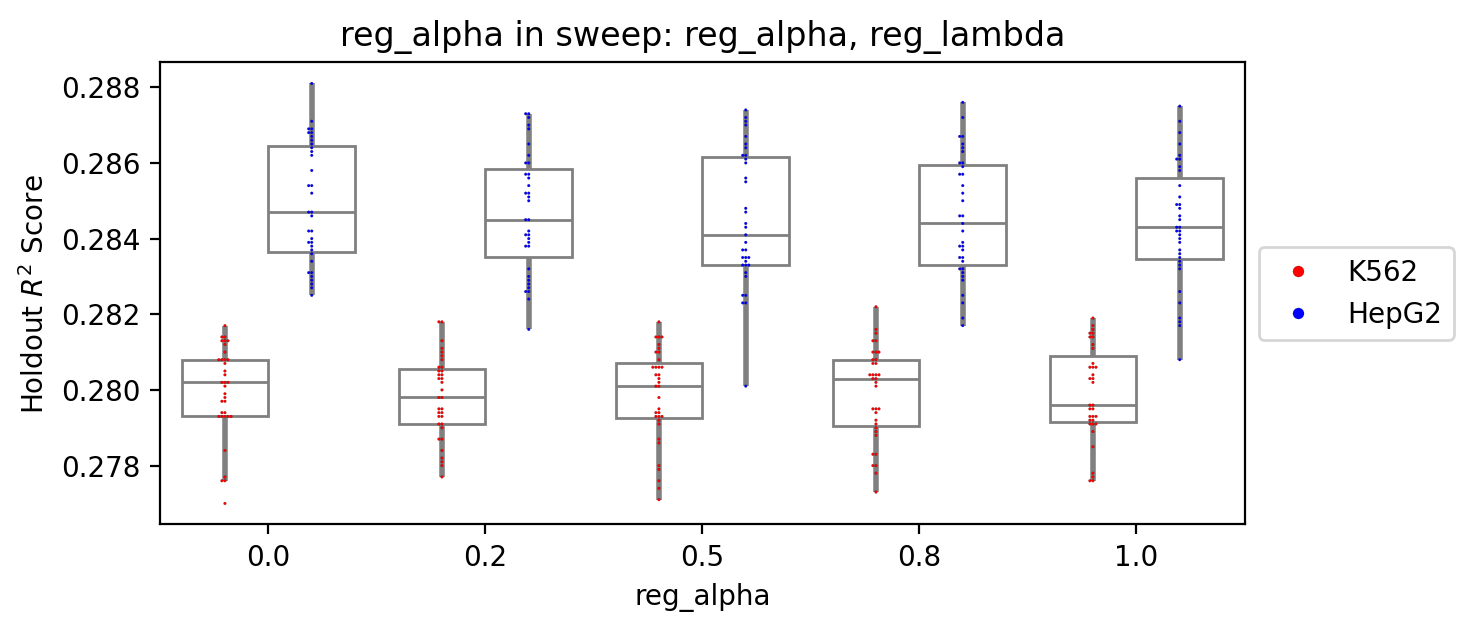

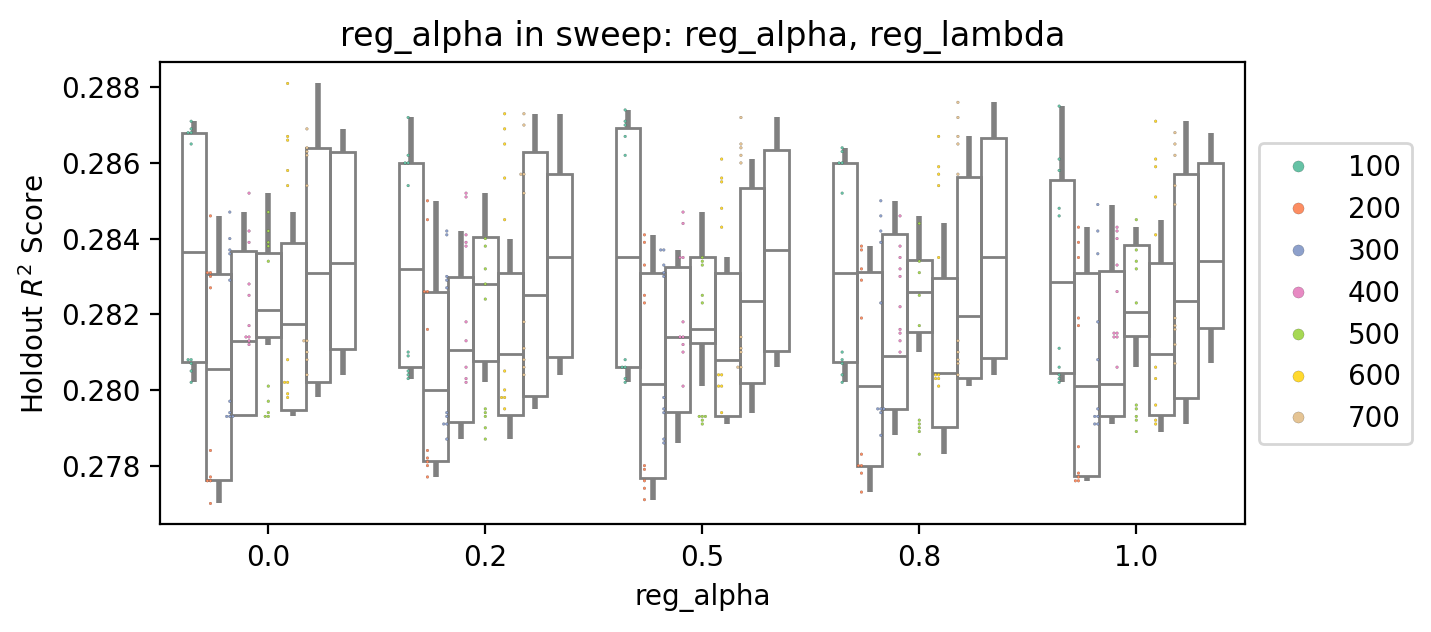

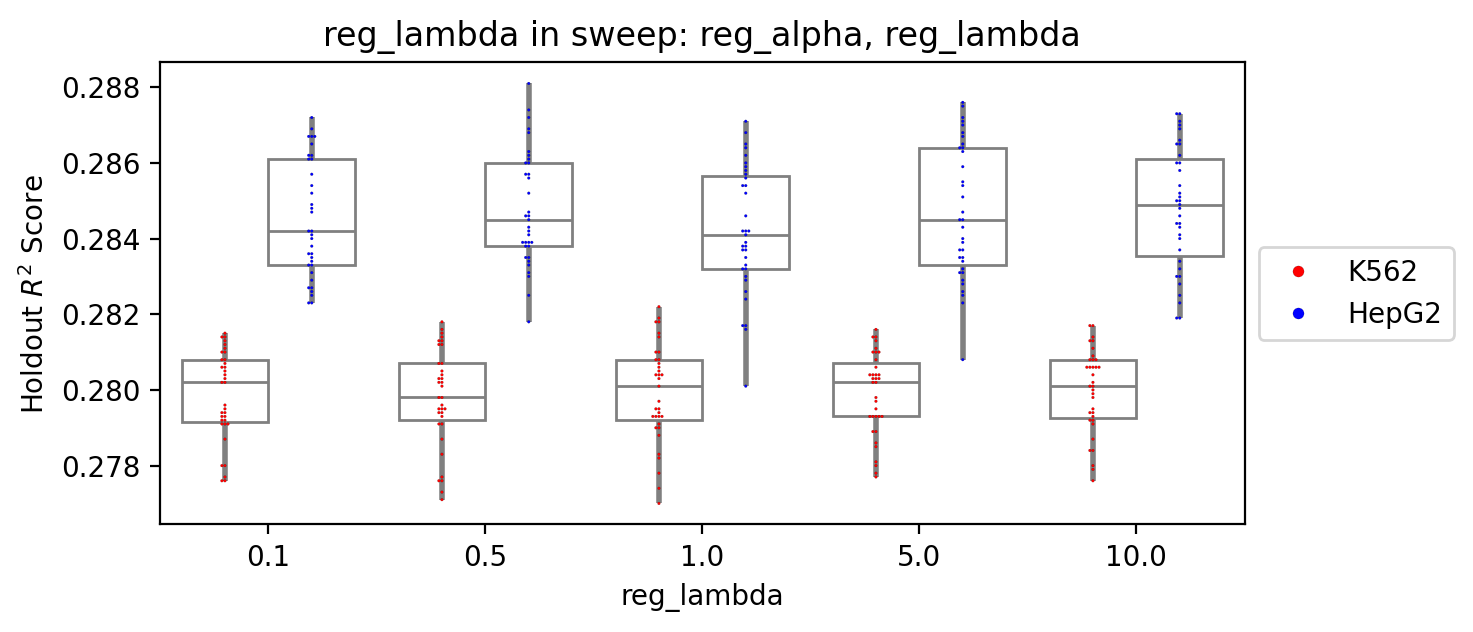

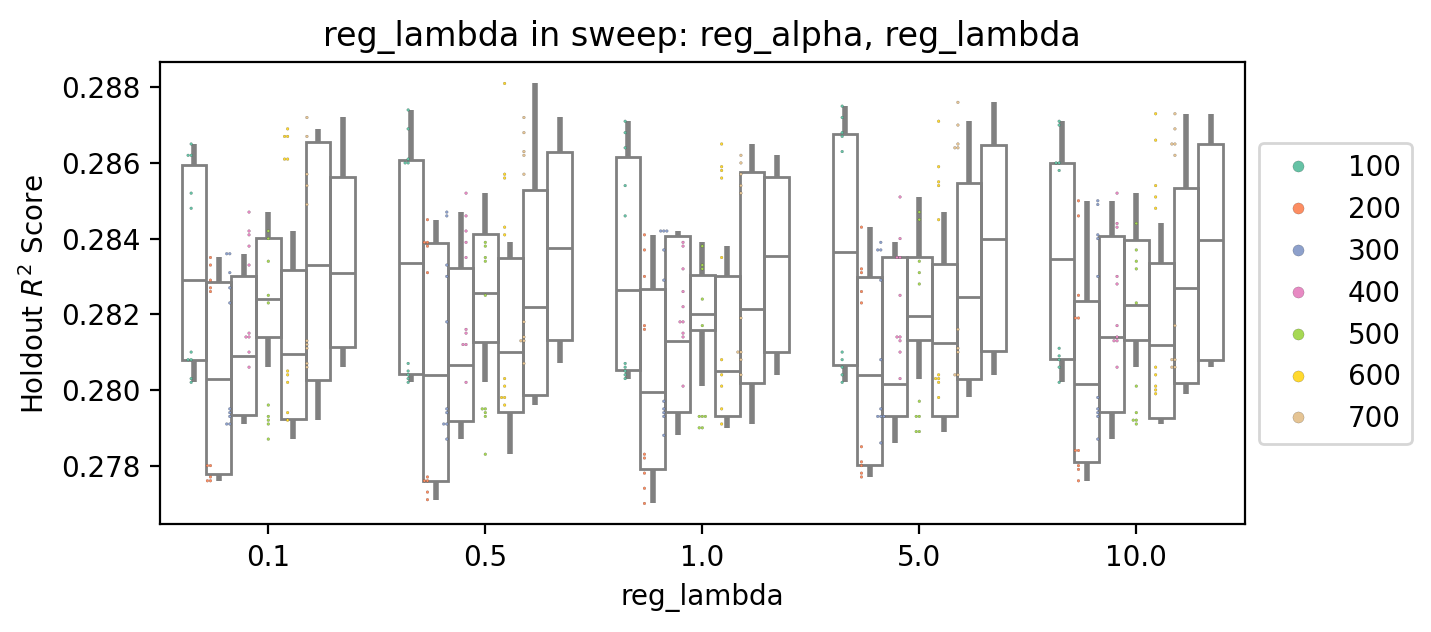

In [8]:
analyzer.plot_interrelated_model_hyperparameter_results_in_1D()

## Higher Dimensional Plotting of Model Sweep Results

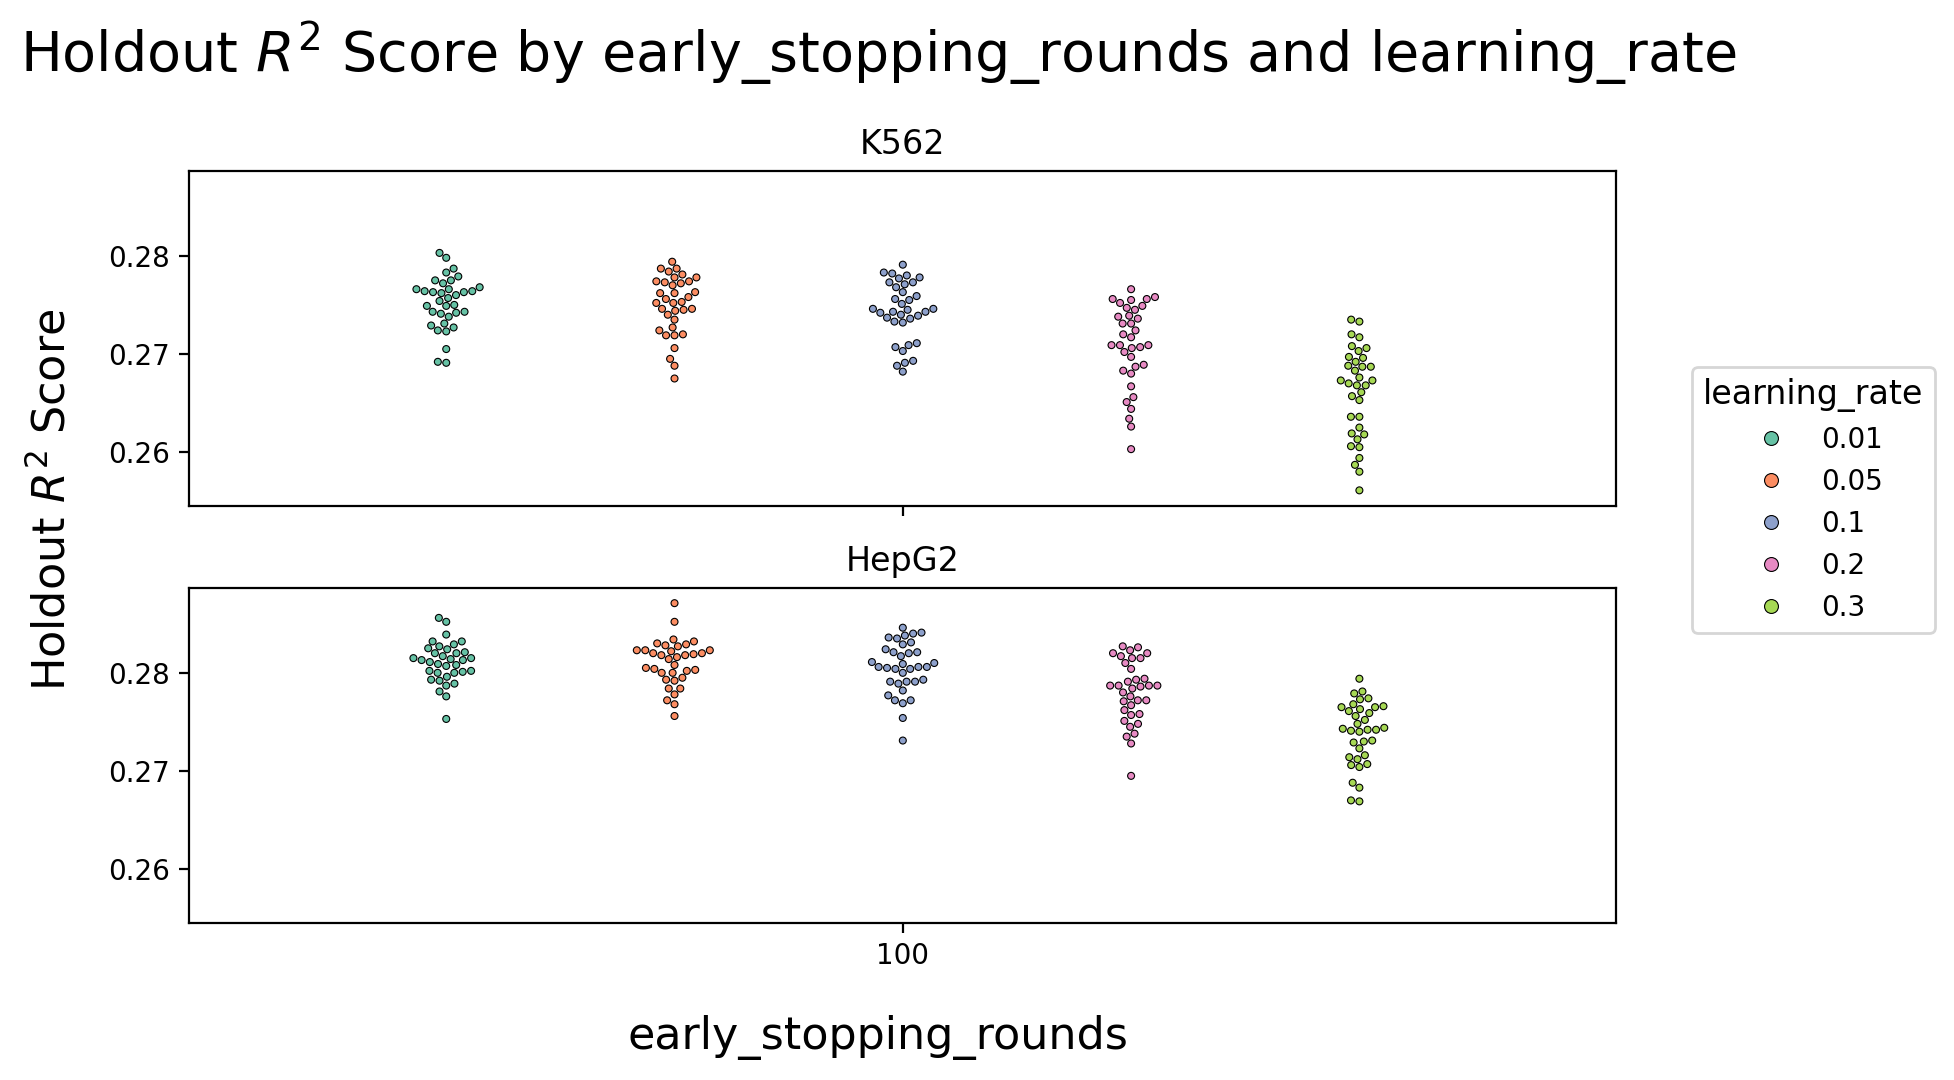

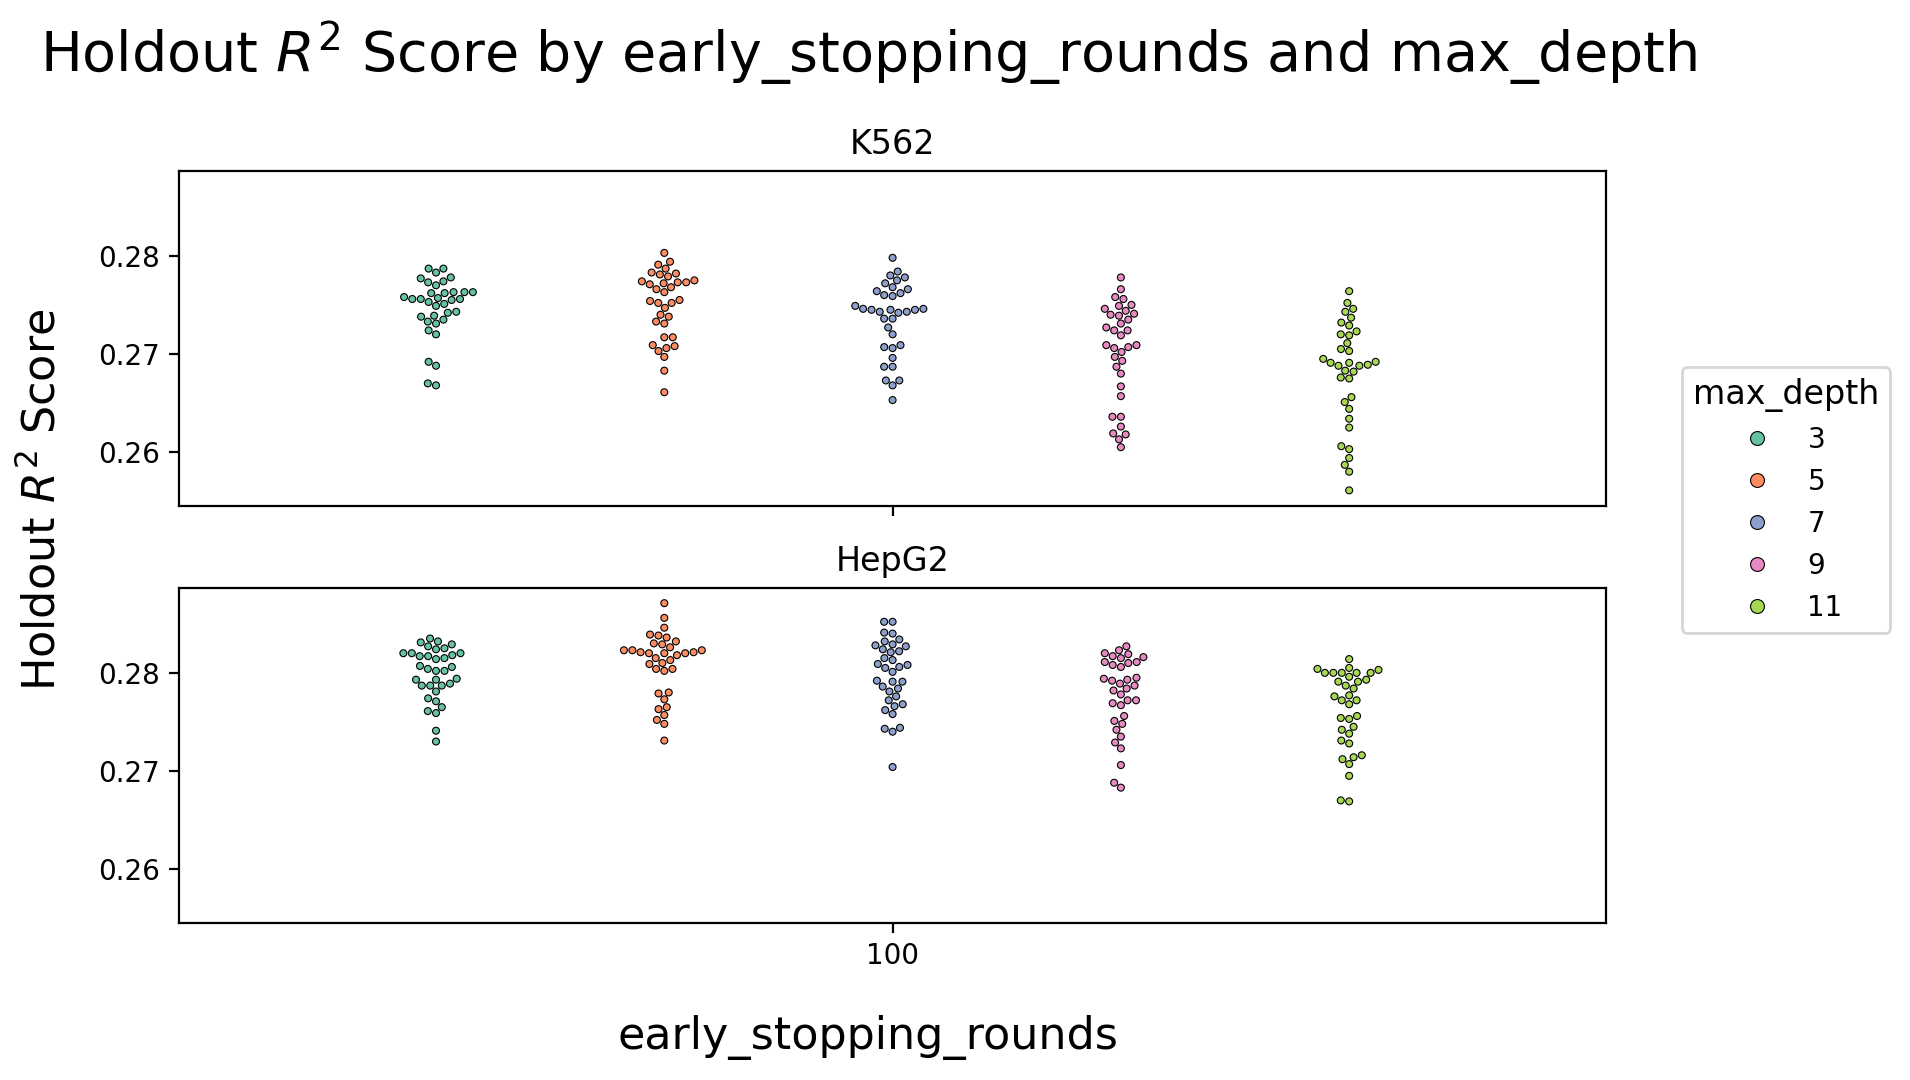

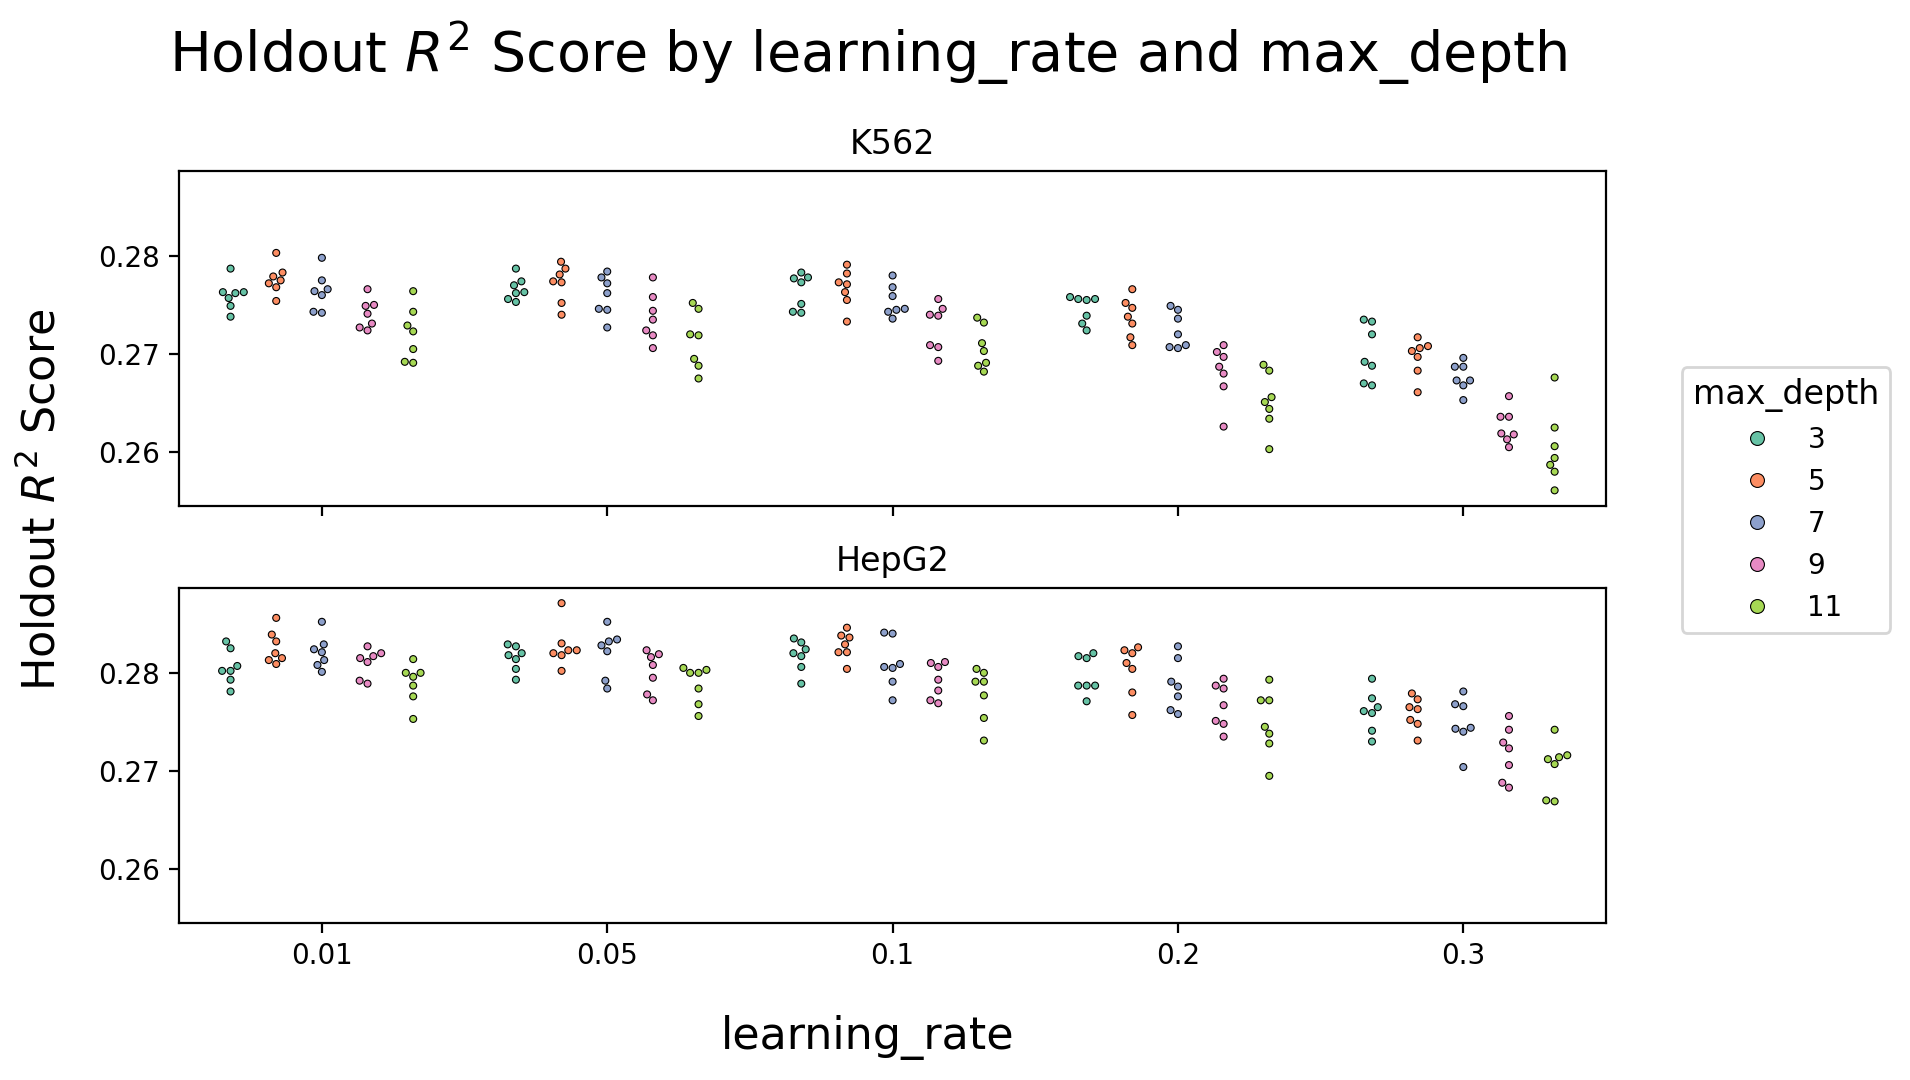

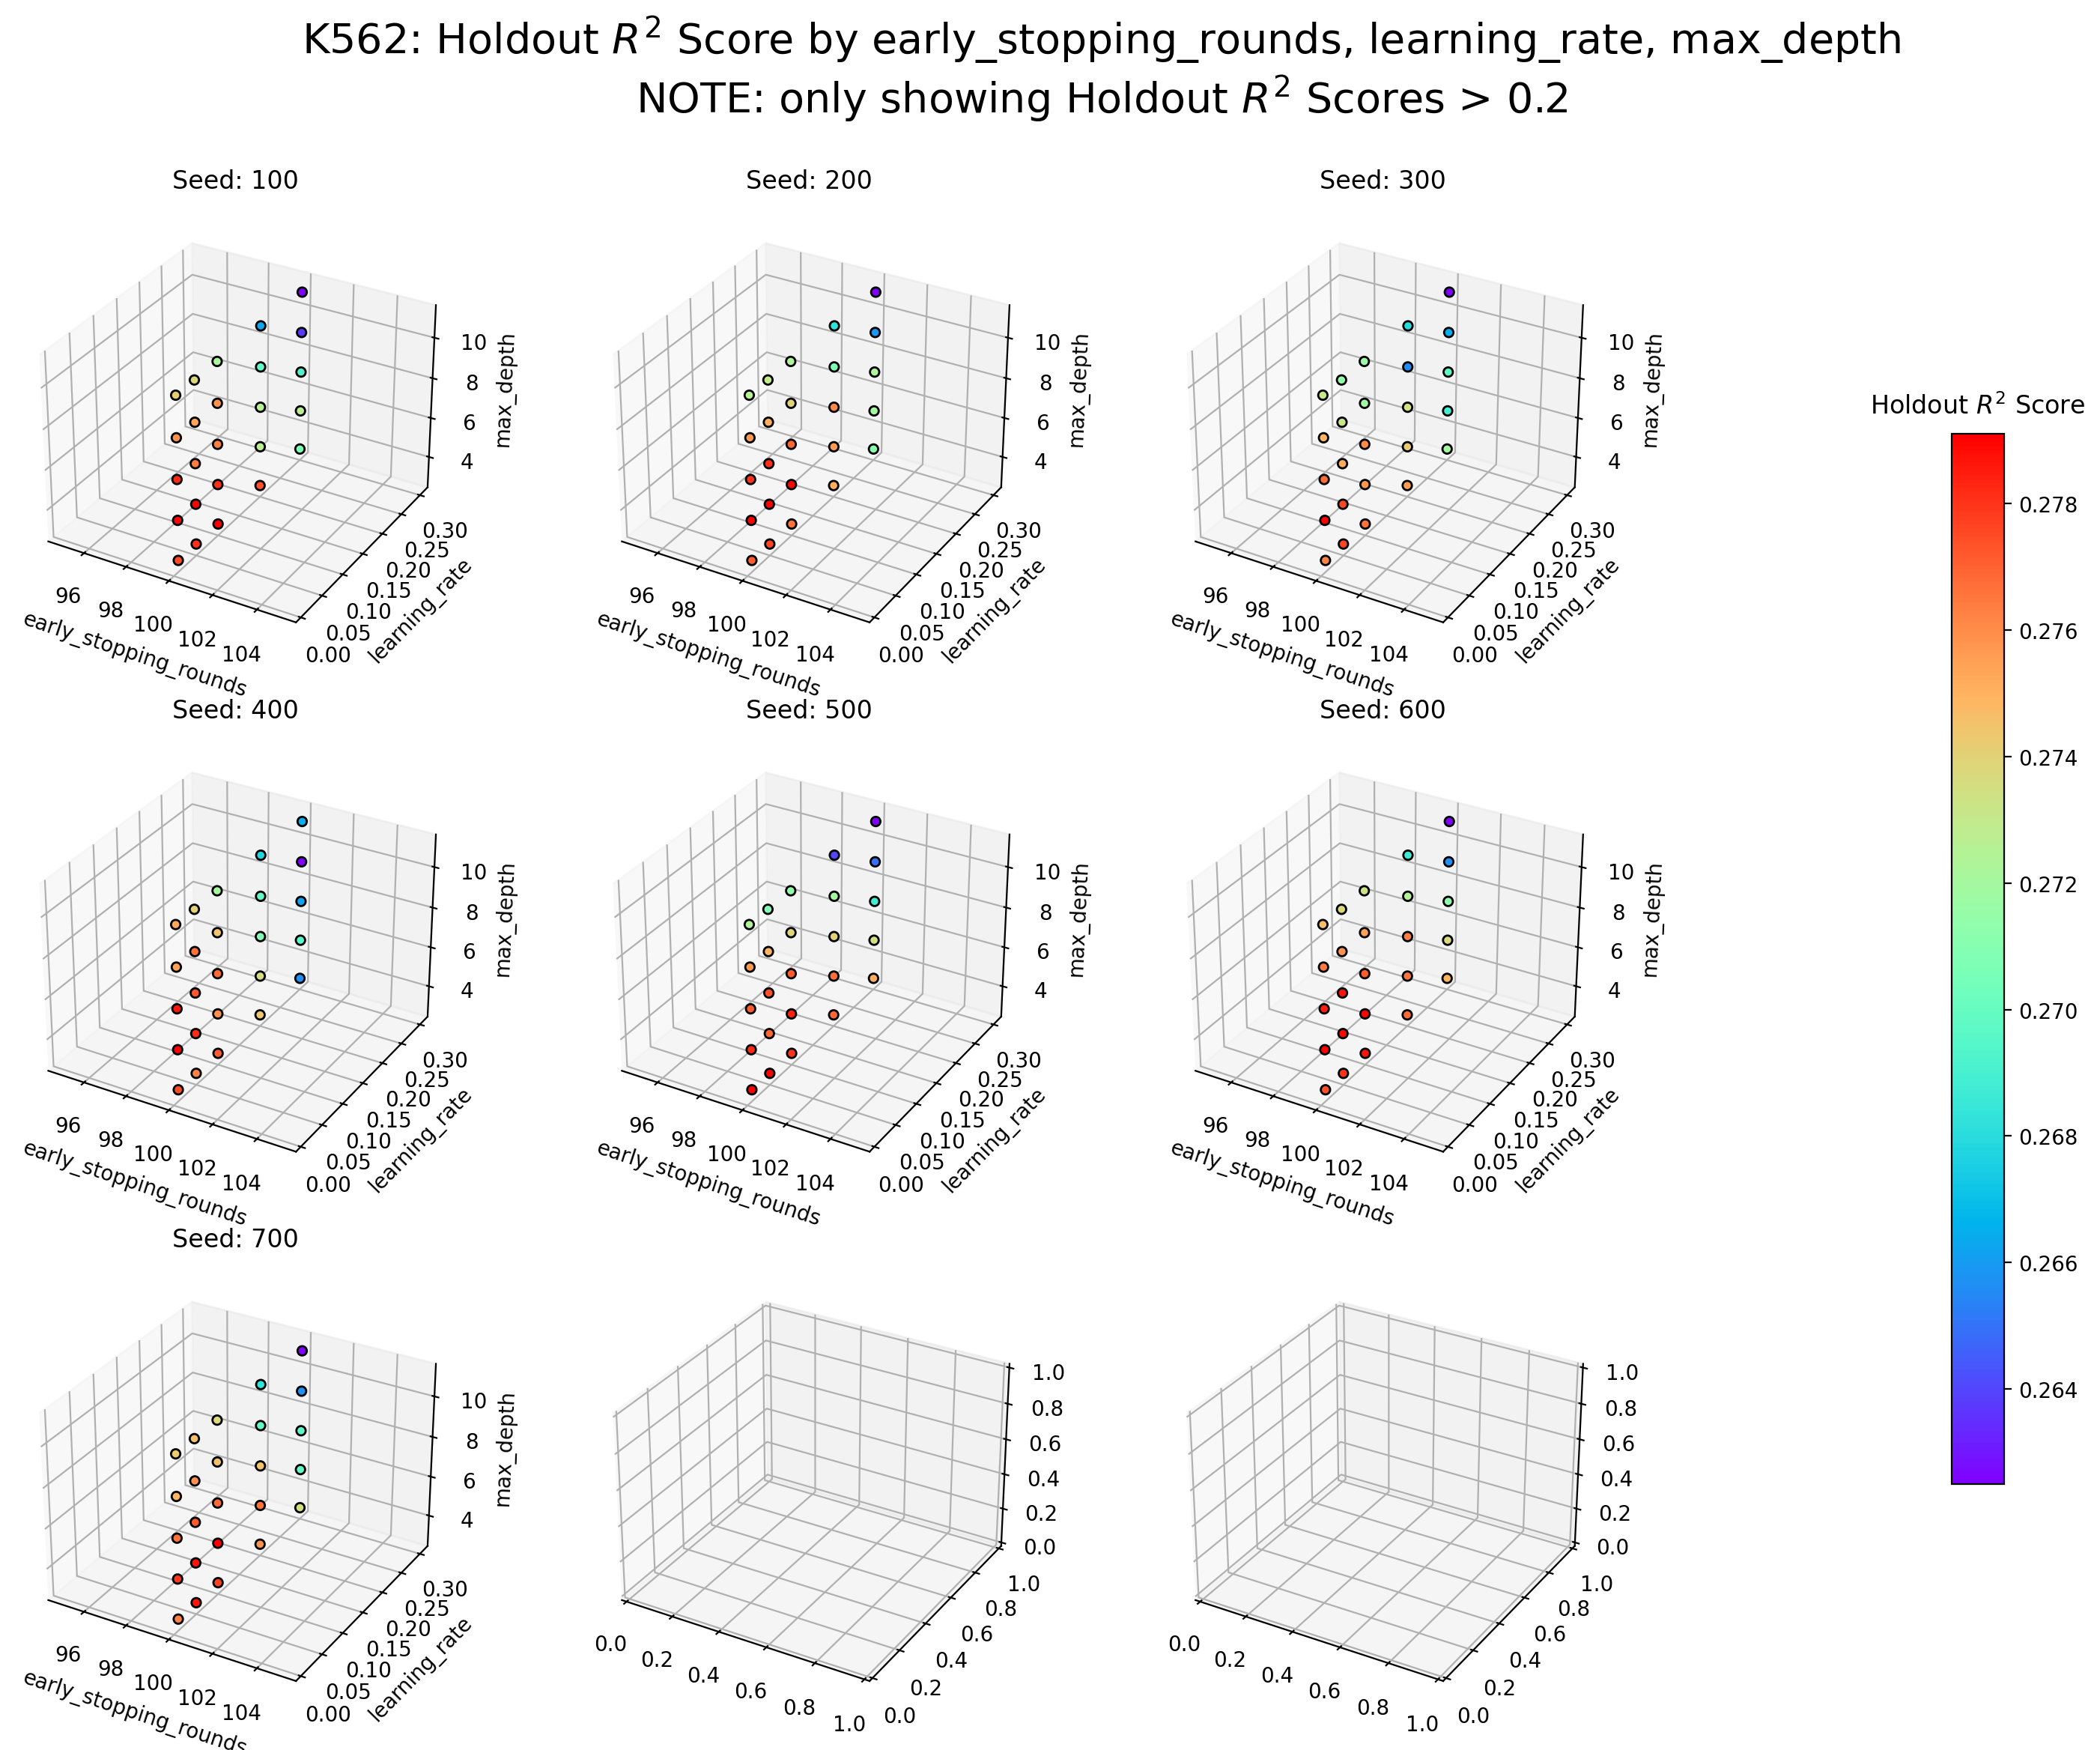

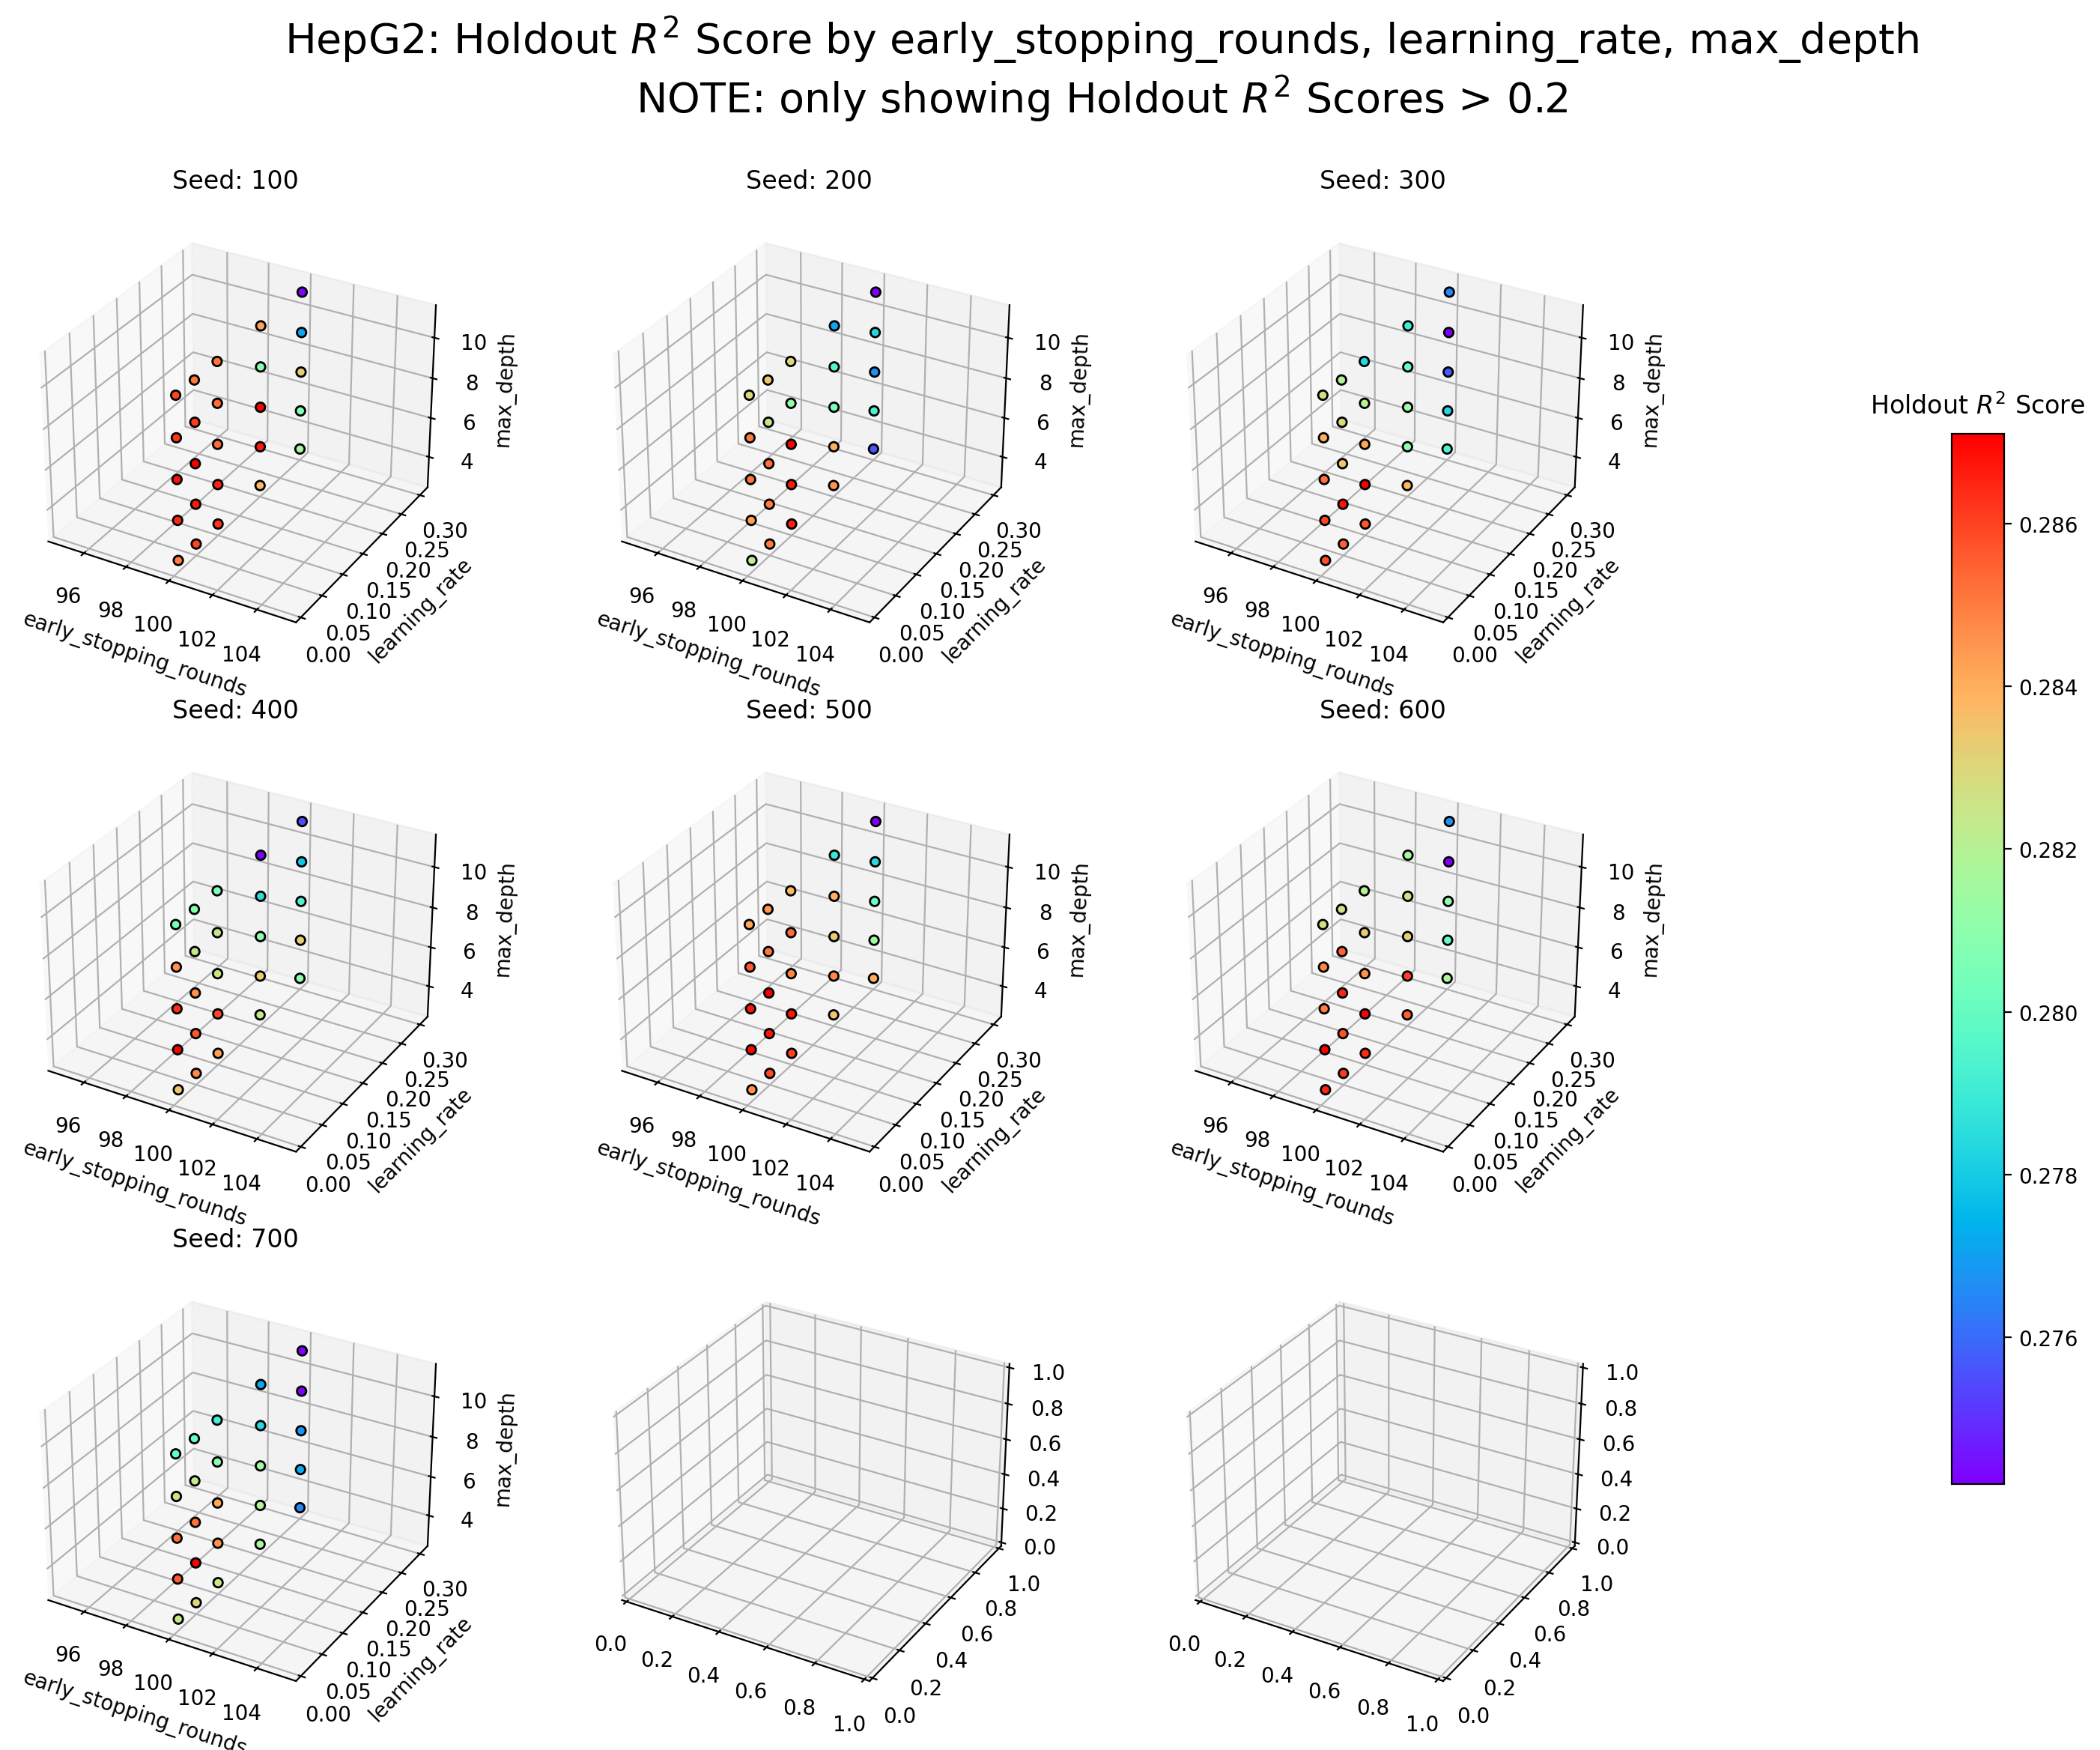

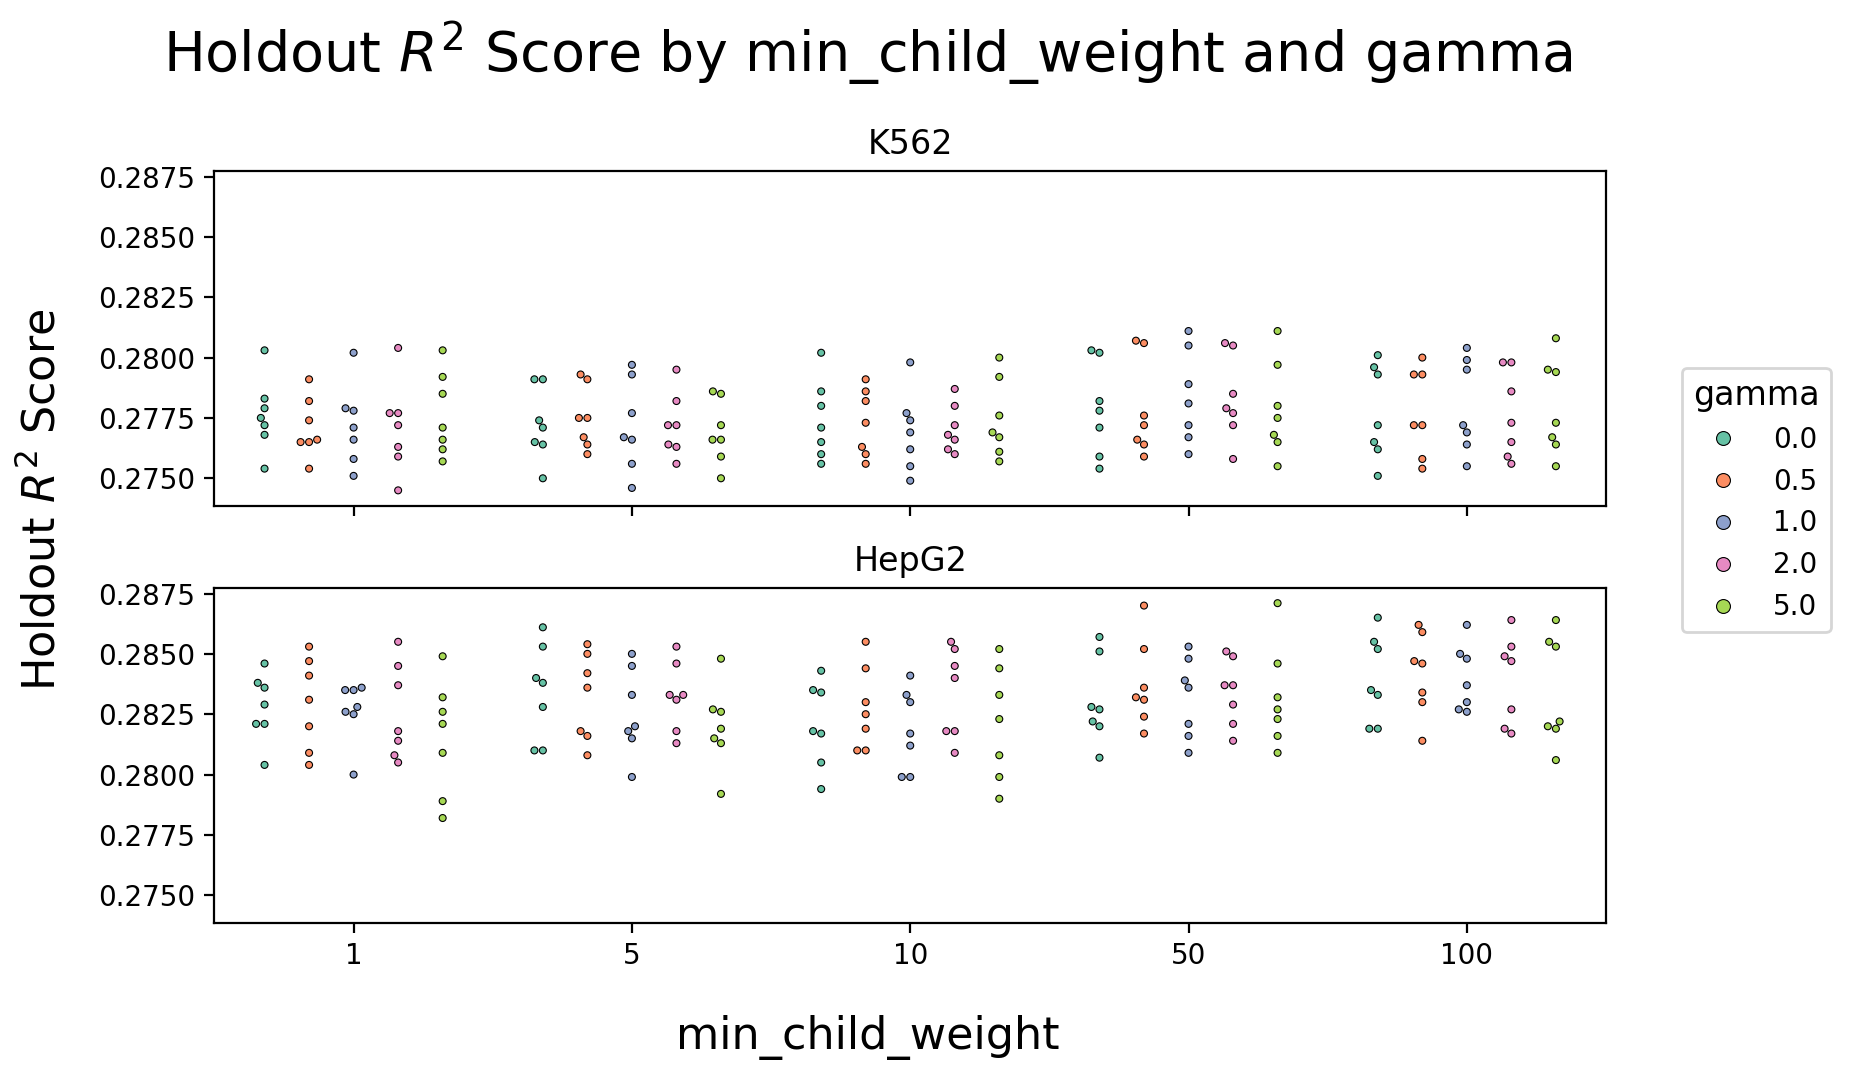

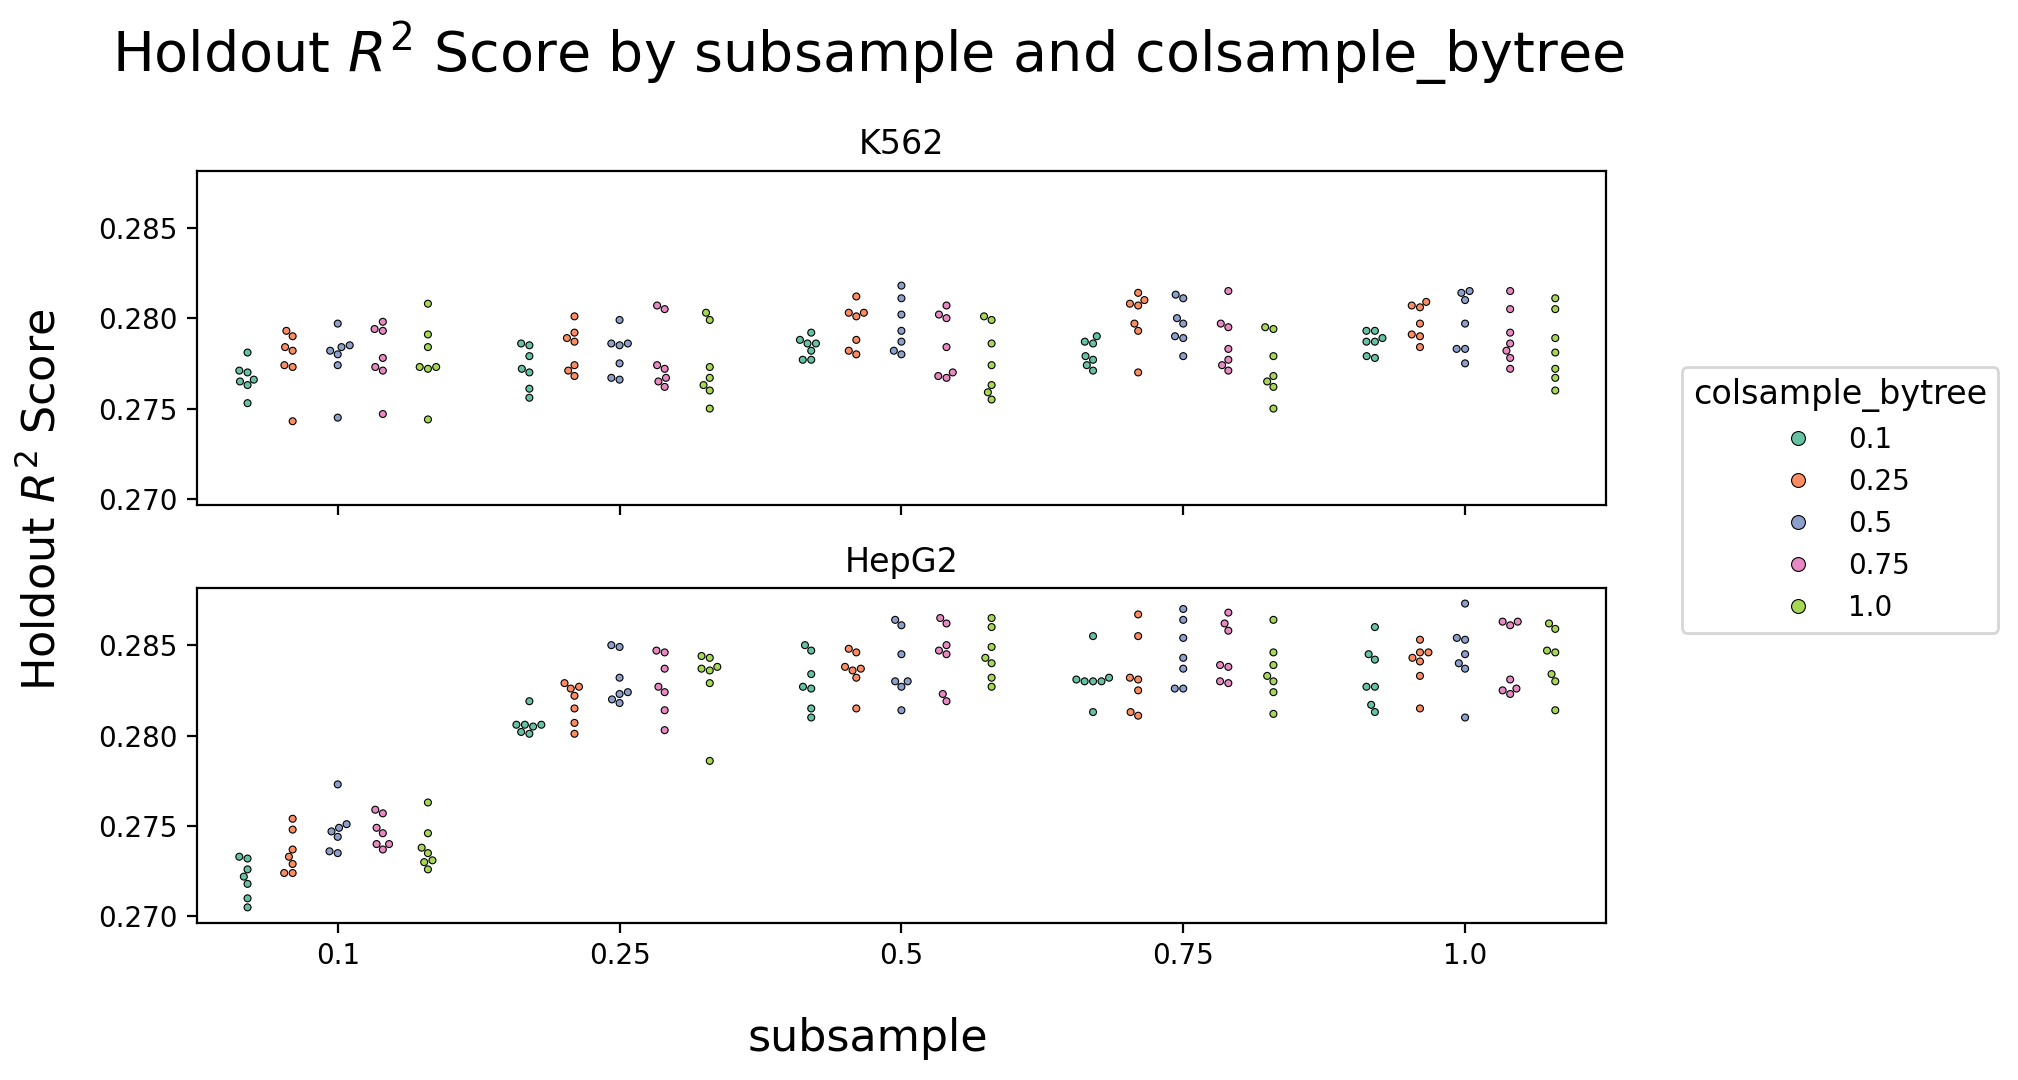

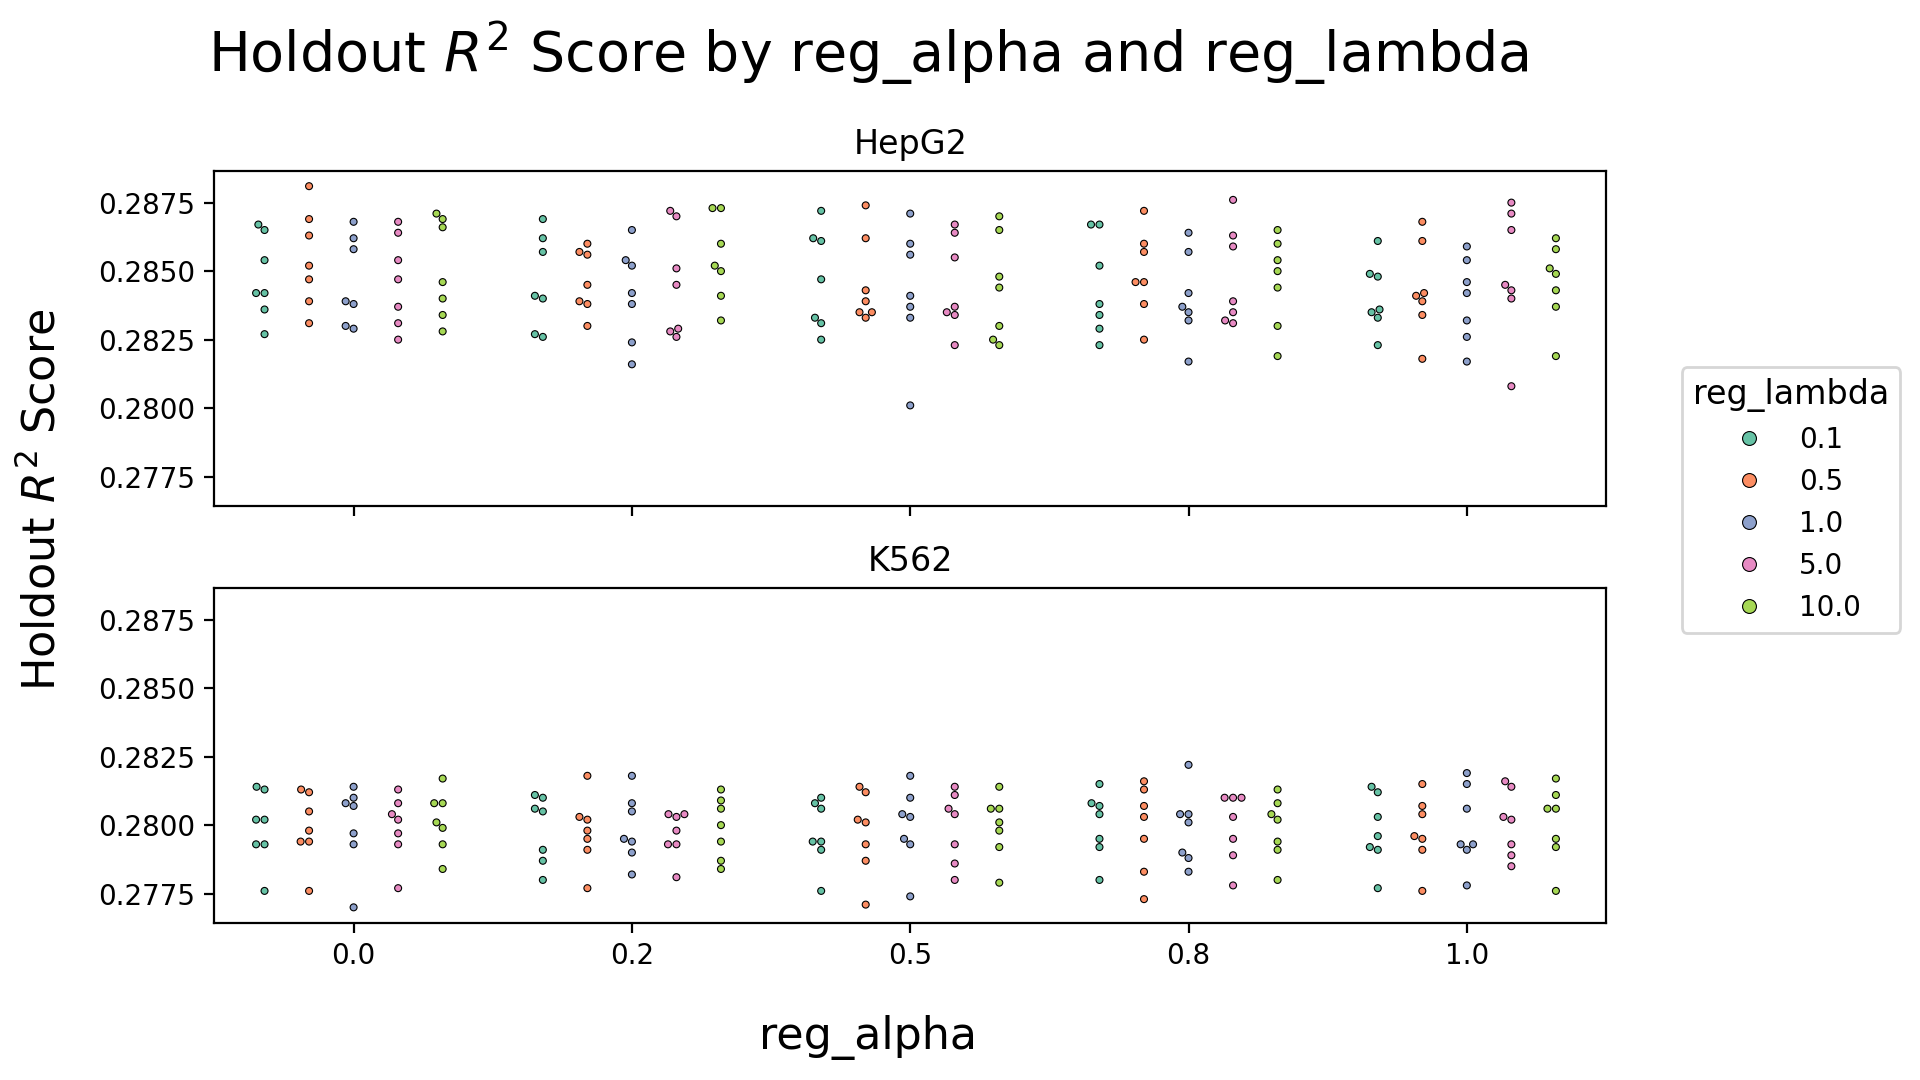

In [9]:
analyzer.plot_interrelated_model_hyperparameter_results_in_higher_dimensions()

## Choosing Top 5 Models After Averaging by Seed

In [10]:
analyzer.show_top_model_configs_after_averaging_by_seed(all_configs=True, linear=False)

2026-03-07 16:27:49.534 | WARNING  | dataset_and_model_parameter_chooser:show_top_model_configs_after_averaging_by_seed:334 - Dropping model hyperparameter duplicates after all sweeps ran. 
Original shape: (1400, 73), new shape: (1358, 73)


,model.early_stopping_rounds,model.learning_rate,model.max_depth,model.min_child_weight,model.gamma,model.subsample,model.colsample_bytree,model.reg_alpha,model.reg_lambda,dataset.data_source.EncodeRBPBindingDataSource.cell_line,avg_holdout_r2_score
0,100,0.10,5,100,0.5,0.75,0.75,0.0,0.5,HepG2,0.285457
1,100,0.10,5,100,0.5,0.75,0.75,0.2,10.0,HepG2,0.285443
2,100,0.10,5,100,0.5,0.75,0.75,0.0,10.0,HepG2,0.285057
3,100,0.10,5,100,0.5,0.75,0.75,1.0,5.0,HepG2,0.284957
4,100,0.10,5,100,0.5,0.75,0.75,0.8,0.5,HepG2,0.284914
5,100,0.10,5,100,0.5,0.75,0.75,0.8,5.0,HepG2,0.284786
6,100,0.10,5,100,0.5,0.75,0.75,0.0,0.1,HepG2,0.284757
7,100,0.10,5,100,0.5,0.75,0.75,0.5,0.1,HepG2,0.284729
8,100,0.10,5,100,0.5,0.75,0.75,0.0,5.0,HepG2,0.284657
9,100,0.10,5,100,0.5,0.75,0.75,0.2,0.5,HepG2,0.284643


<h1 style="color: teal; font-weight: bold; font-size: 48px;">Outer Loop Holdout R2 Scores</h1>

In [ ]:
run_ids = analyzer.get_run_ids_for_outer_loop_holdout_r2_scores()
run_ids

In [11]:
analyzer.assert_outer_loop_holdout_r2_scores()

2026-03-07 16:28:17.332 | WARNING  | dataset_and_model_parameter_chooser:show_top_model_configs_after_averaging_by_seed:334 - Dropping model hyperparameter duplicates after all sweeps ran. 
Original shape: (1400, 73), new shape: (1358, 73)
2026-03-07 16:28:17.454 | WARNING  | dataset_and_model_parameter_chooser:get_run_ids_for_outer_loop_holdout_r2_scores:700 - 2 runs found for config: {'model.early_stopping_rounds': 100, 'model.learning_rate': 0.01, 'model.max_depth': 5, 'model.min_child_weight': 50, 'model.gamma': 1.0, 'model.subsample': 0.75, 'model.colsample_bytree': 0.25, 'model.reg_alpha': 0.0, 'model.reg_lambda': 1.0, 'dataset.data_source.EncodeRBPBindingDataSource.cell_line': 'K562', 'avg_holdout_r2_score': 0.2799857142857143}. 
Choosing the first one after sorting by all columns.
2026-03-07 16:28:17.477 | SUCCESS  | dataset_and_model_parameter_chooser:get_run_ids_for_outer_loop_holdout_r2_scores:711 - Saved run IDs to ../output/chosen_models_for_outer_loop/outer_loop_holdout_r

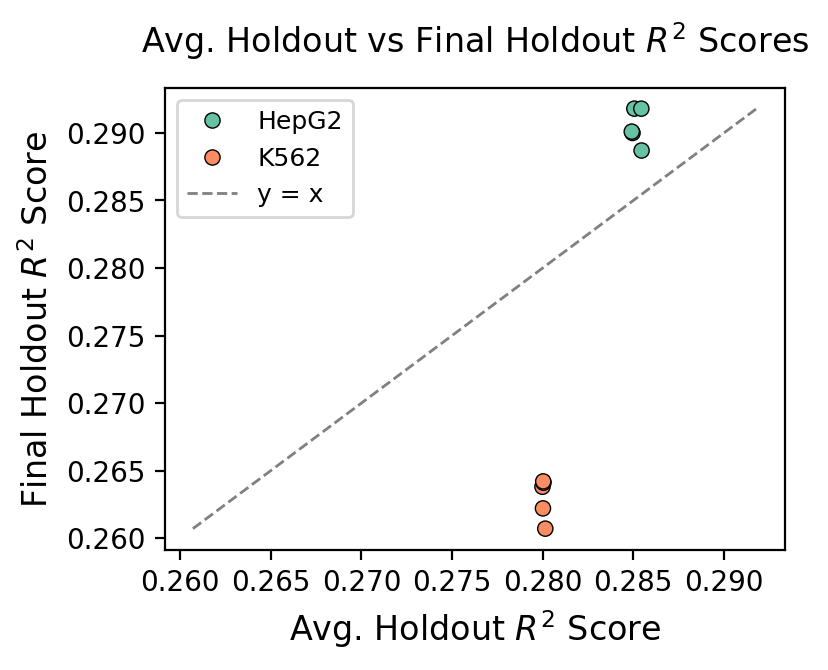

,model.early_stopping_rounds,model.learning_rate,model.max_depth,model.min_child_weight,model.gamma,model.subsample,model.colsample_bytree,model.reg_alpha,model.reg_lambda,run_id,dataset.data_source.EncodeRBPBindingDataSource.cell_line,avg_holdout_r2_score,outer_loop_holdout_r2_score
3,100,0.10,5,100,0.5,0.75,0.75,0.0,0.5,3ra4dgdk,HepG2,0.285457,0.2887
9,100,0.10,5,100,0.5,0.75,0.75,1.0,5.0,s9ukk8c8,HepG2,0.284957,0.2900
1,100,0.10,5,100,0.5,0.75,0.75,0.8,0.5,0t3m7p4m,HepG2,0.284914,0.2901
7,100,0.10,5,100,0.5,0.75,0.75,0.0,10.0,h6o44fm9,HepG2,0.285057,0.2918
8,100,0.10,5,100,0.5,0.75,0.75,0.2,10.0,nfucc14m,HepG2,0.285443,0.2918
4,100,0.01,5,50,1.0,0.75,0.25,0.0,10.0,55c789s6,K562,0.280143,0.2607
2,100,0.01,5,50,1.0,0.75,0.25,0.8,0.1,1hx0bzrf,K562,0.280014,0.2622
0,100,0.01,5,50,1.0,0.75,0.25,0.0,1.0,90qo5vz2,K562,0.279986,0.2638
5,100,0.01,5,50,1.0,0.75,0.25,1.0,10.0,df0brkxb,K562,0.280043,0.2641
6,100,0.01,5,50,1.0,0.75,0.25,1.0,5.0,e4jt6jyq,K562,0.280029,0.2642


In [12]:
analyzer.inner_fold_vs_outer_fold_r2_score()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">ElasticNet Results & Outer Loop Holdout Scores & OLS Regression</h1>

In [ ]:
analyzer.plot_OLS_results()

In [13]:
analyzer.show_top_model_configs_after_averaging_by_seed(
        all_configs=True, 
        linear=True
    ).sort_values(
        by='avg_holdout_r2_score',
        ascending=False
    )

2026-03-07 16:28:59.199 | WARNING  | dataset_and_model_parameter_chooser:show_top_model_configs_after_averaging_by_seed:334 - Dropping model hyperparameter duplicates after all sweeps ran. 
Original shape: (1092, 61), new shape: (1092, 61)


,model.l1_ratio,model.alpha,dataset.data_source.EncodeRBPBindingDataSource.cell_line,avg_holdout_r2_score
0,1.00,0.0001,HepG2,0.187029
1,0.90,0.0001,HepG2,0.186886
2,0.75,0.0001,HepG2,0.186386
3,0.25,0.0005,HepG2,0.186029
4,0.10,0.0010,HepG2,0.185571
5,0.10,0.0005,HepG2,0.185429
6,0.50,0.0001,HepG2,0.184557
10,0.10,0.0010,K562,0.184343
11,0.25,0.0005,K562,0.184214
12,1.00,0.0001,K562,0.183700


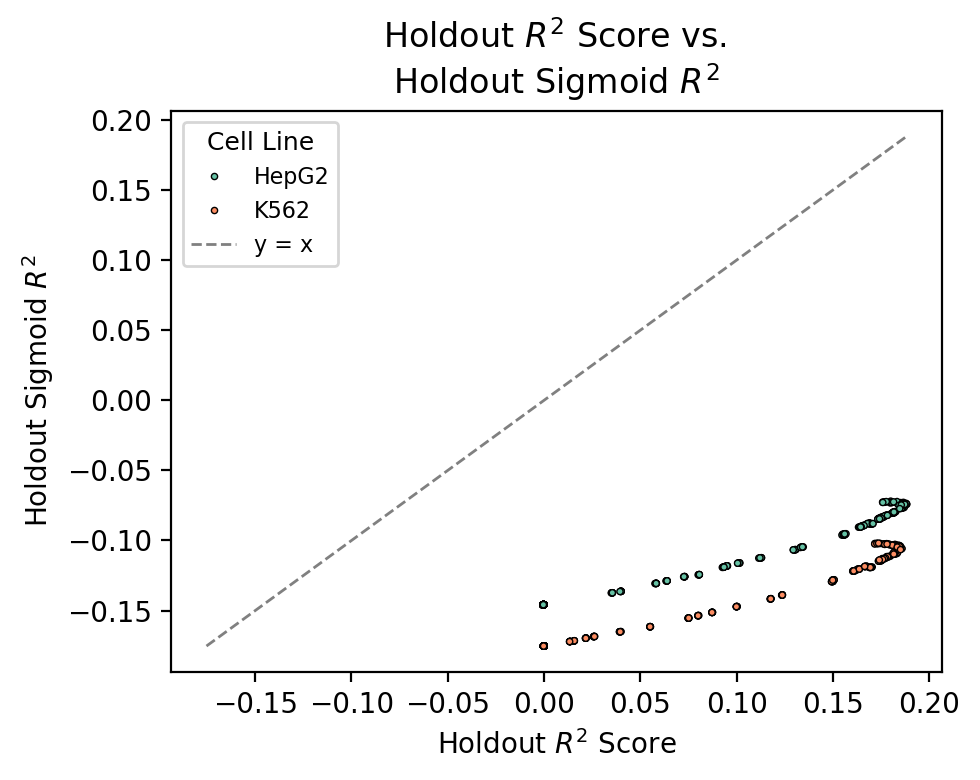

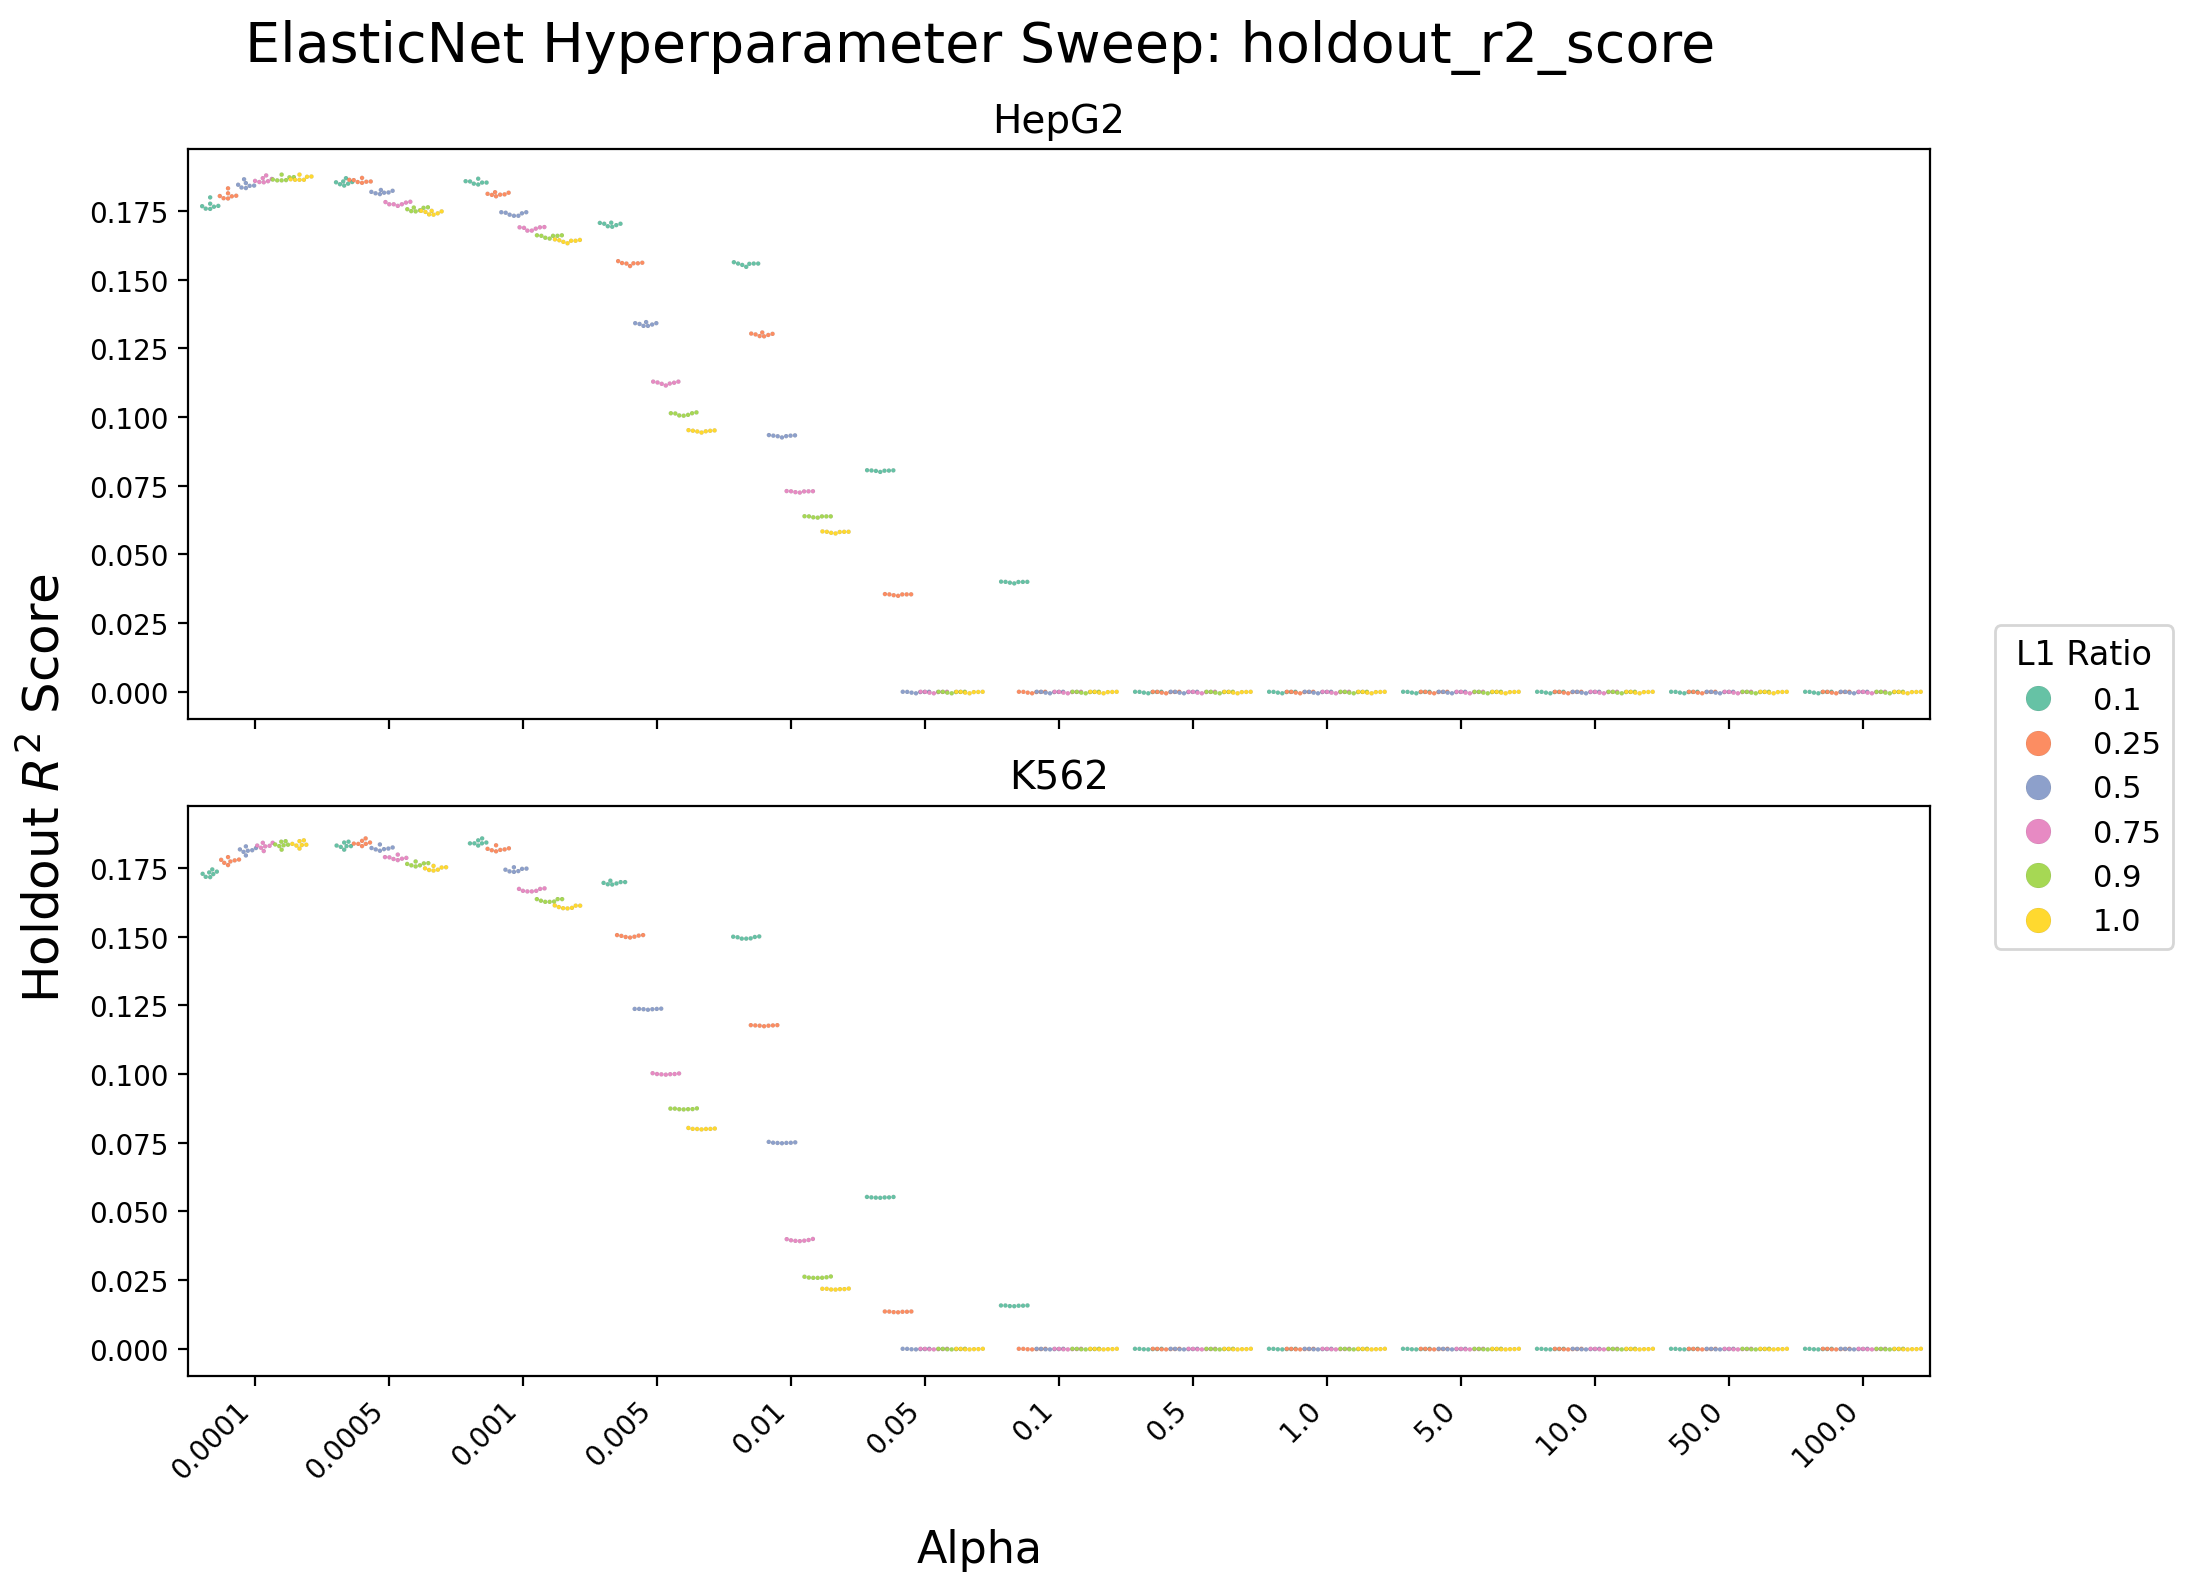

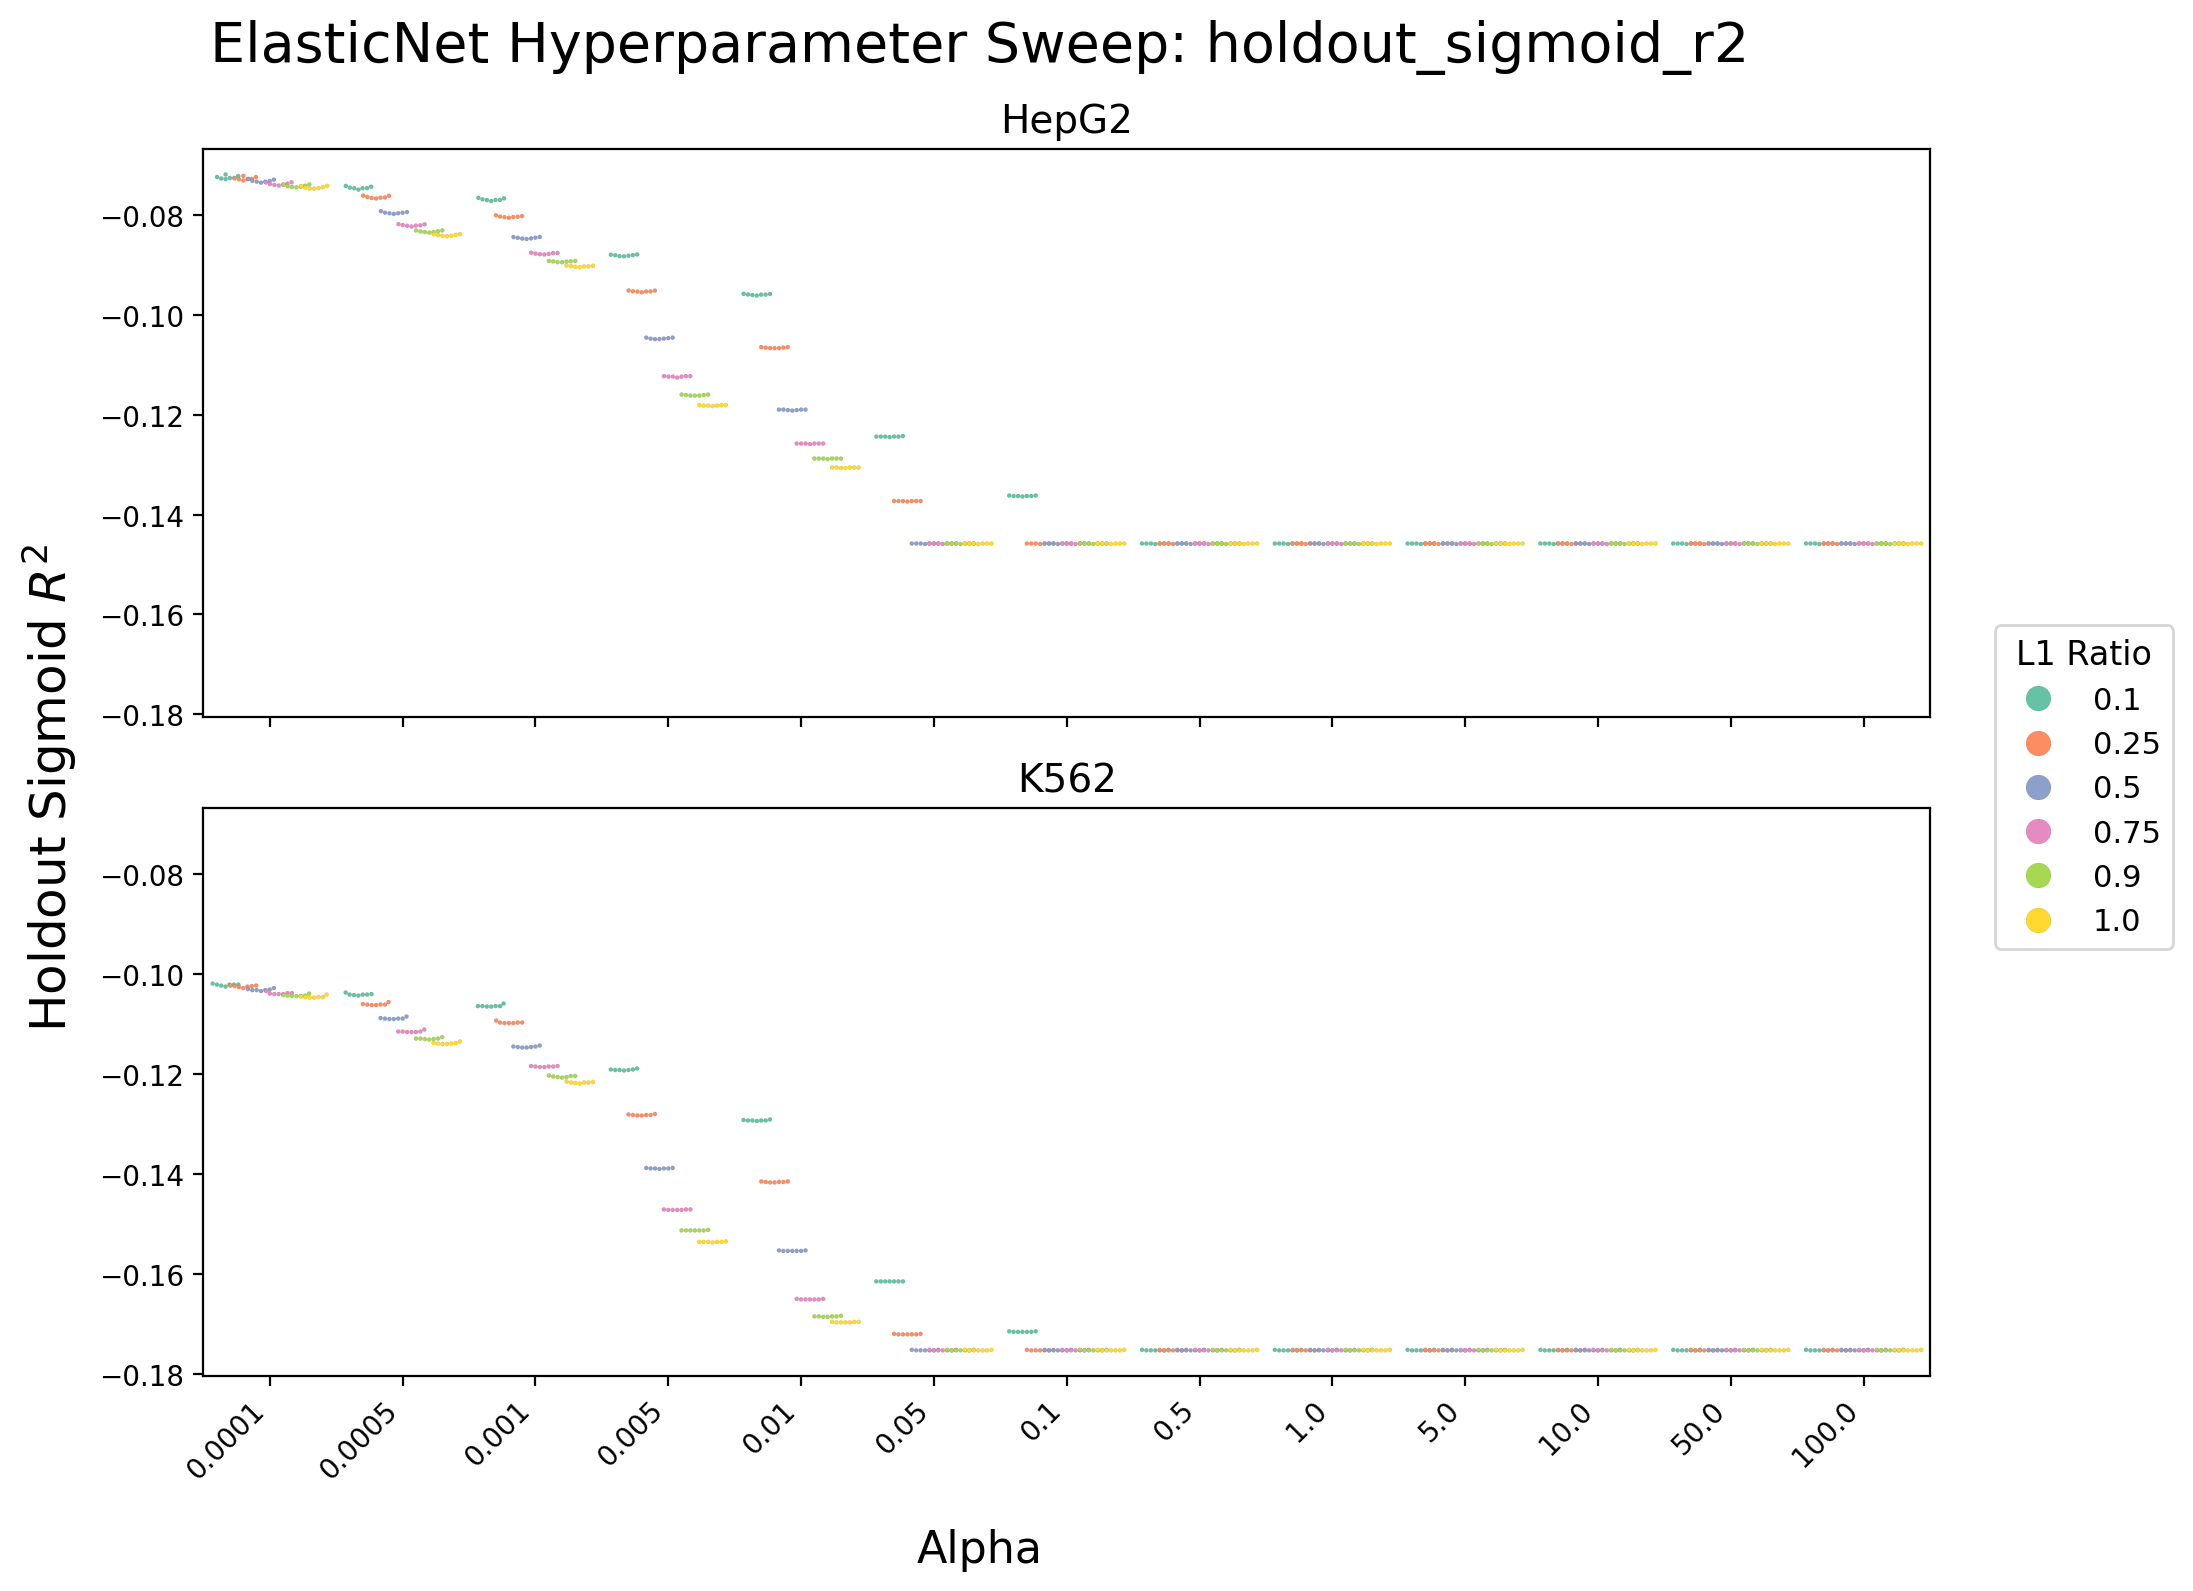

In [14]:
analyzer.plot_elasticnet_results()

In [ ]:
analyzer.get_elasticnet_run_ids()

2026-03-07 16:29:18.071 | WARNING  | dataset_and_model_parameter_chooser:show_top_model_configs_after_averaging_by_seed:334 - Dropping model hyperparameter duplicates after all sweeps ran. 
Original shape: (1092, 61), new shape: (1092, 61)


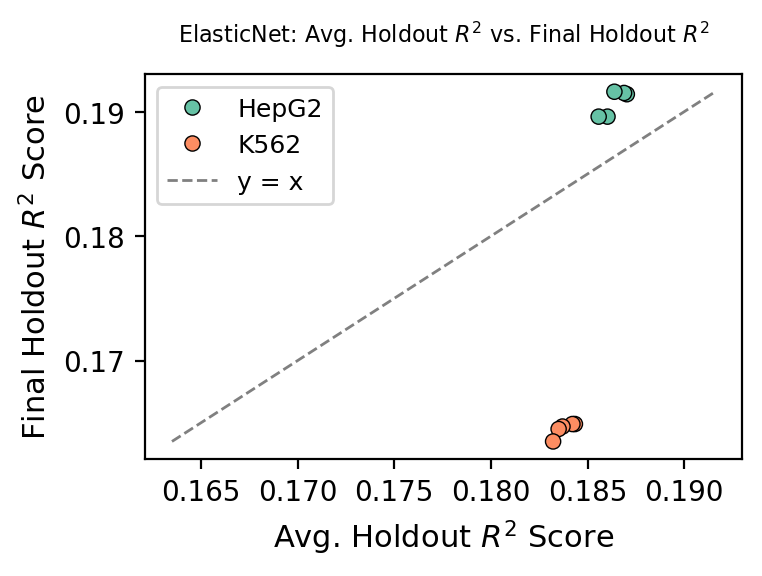

In [15]:
analyzer.plot_elasticnet_outer_vs_avg_inner_r2()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Output Model Config Parameters for Replication Downstream</h1>

In [ ]:
analyzer.create_model_parameter_configs_for_replication()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Model Variations</h1>

In [ ]:
analyzer.visualize_model_variation_results()